# Dataset "Bank Customer"

## Classification task

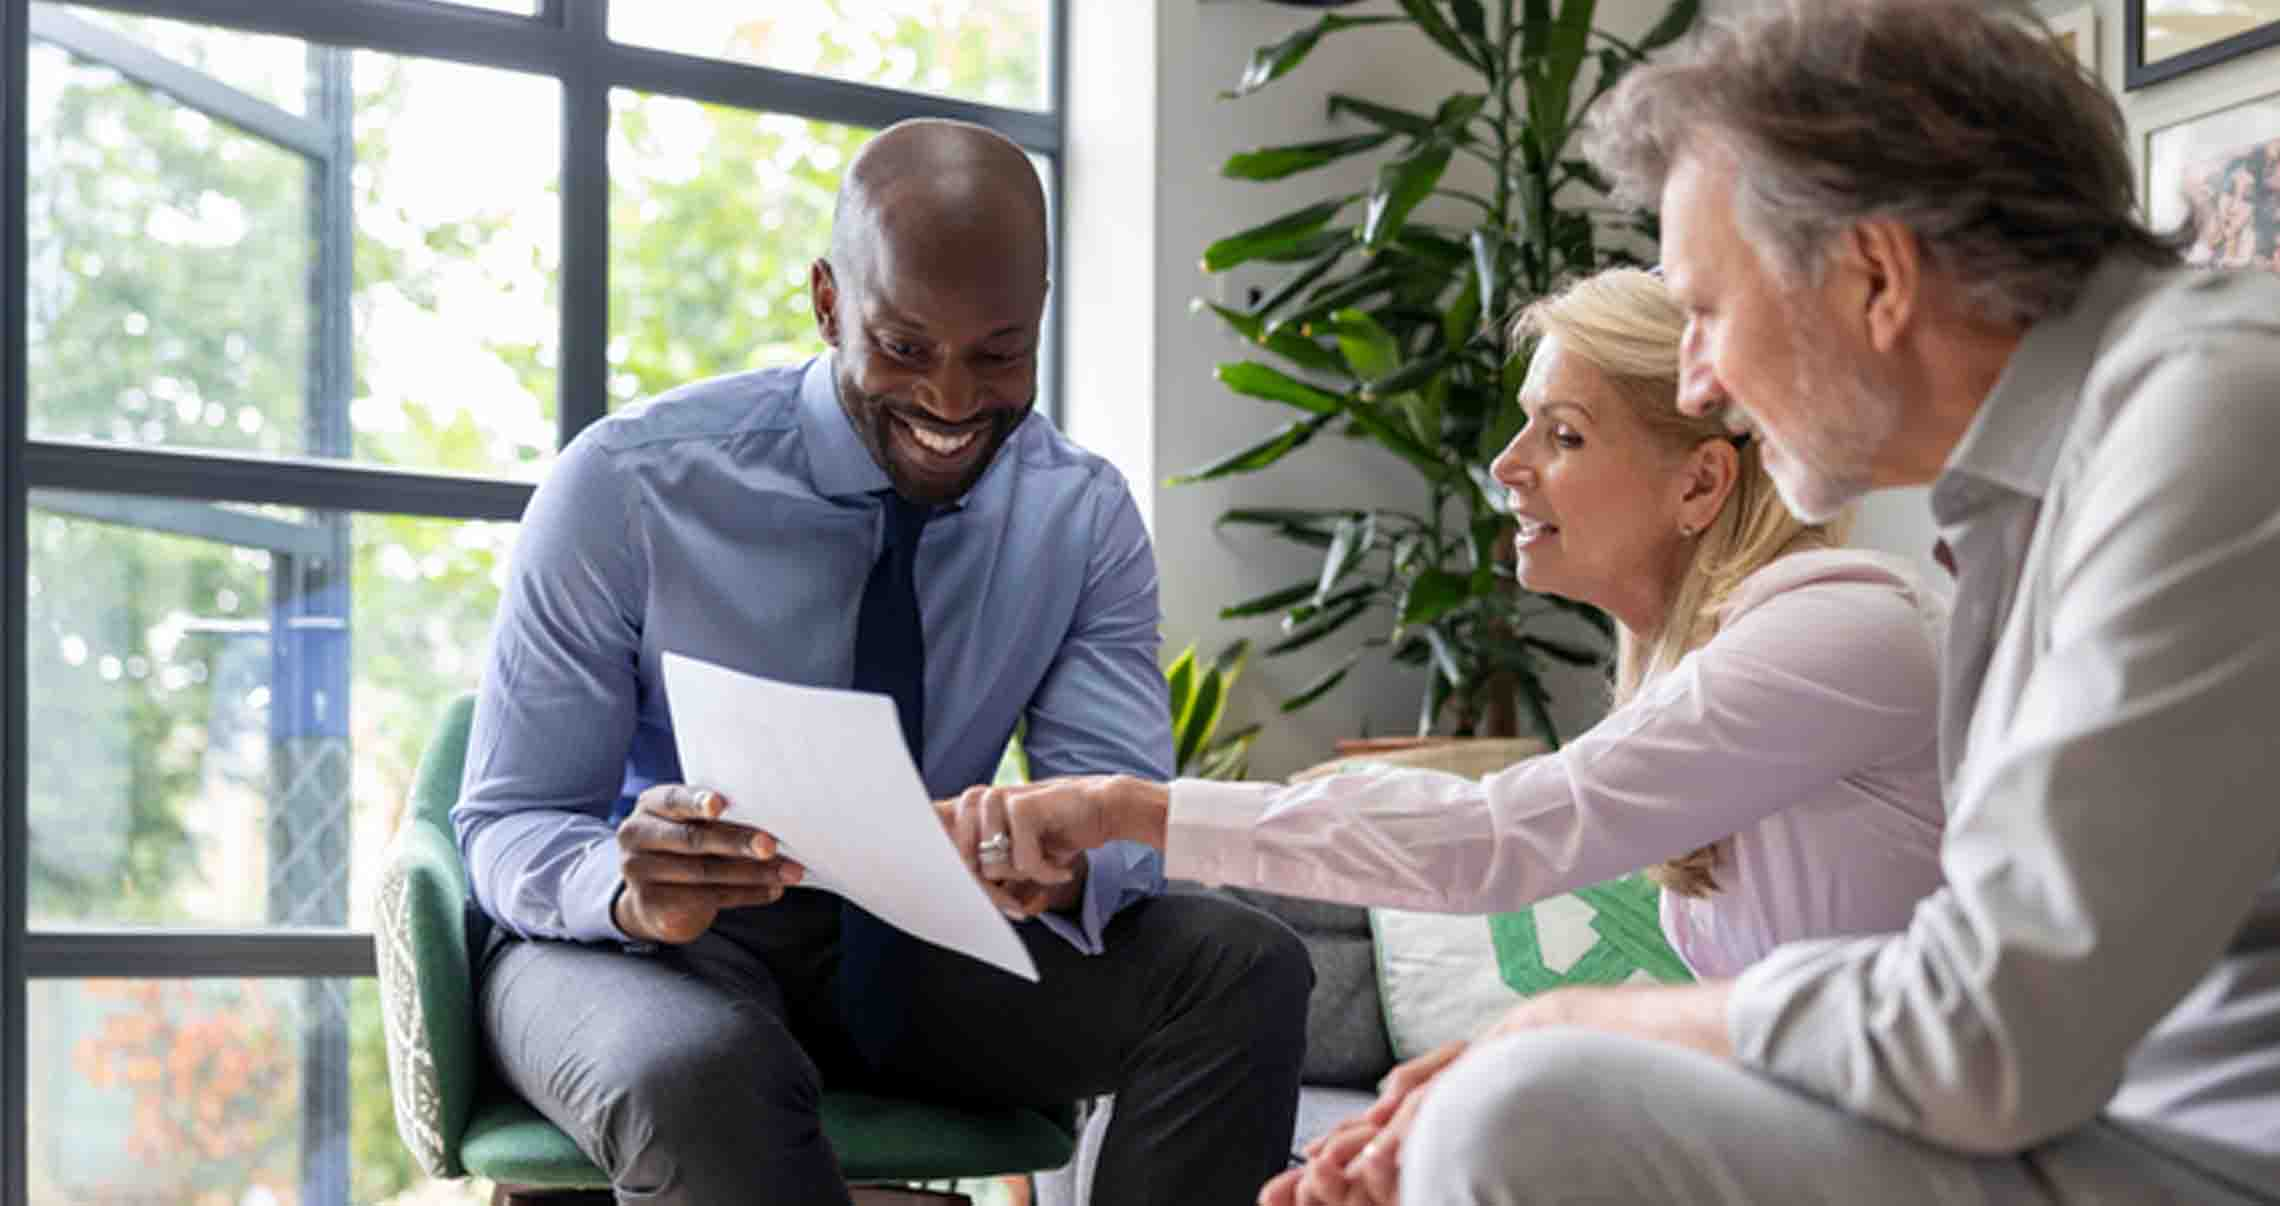

Учебный/синтетический набор данных, в котором описаны клиенты банка.  
Основная задача-**спрогнозировать, уйдёт ли клиент на пенсию / прекратит пользоваться услугами банка**.

### Целевая переменная
- **Retire**  
  - `0` → клиент остался  
  - `1` → клиент ушёл  


### Переменные

| Переменная       | Описание                                   |
|------------------|--------------------------------------------|
| **Customer ID**  | Уникальный номер клиента                   |
| **Age**          | Возраст клиента                            |
| **401k_savings** | Накопления на пенсионных счетах            |
| **Retire**       | Целевая переменная (0 — остался, 1 — ушёл) |

### Тип задачи
- **Классификация**  
Задача предсказать, уйдёт клиент или останется, исходя из его характеристик.

## Импорт библиотек

In [1]:
import time                               # работа со временем (замеры, задержки и т.п.)
import numpy as np                        # работа с массивами и числовыми вычислениями
import pandas as pd                       # работа с таблицами (DataFrame)
import scipy.stats as stats               # статистические функции и распределения
import matplotlib.pyplot as plt           # базовые графики
import seaborn as sns                     # статистическая визуализация, красивые графики поверх matplotlib
from sklearn.experimental import enable_iterative_imputer  # активирует IterativeImputer (экспериментальный)
from sklearn.impute import (
    SimpleImputer,                        # простая импутация (mean/median/most_frequent/constant)
    IterativeImputer,                     # итеративная импутация через модели
    KNNImputer)                           # импутация через KNN (соседи)
from feature_engine.imputation import (
    MeanMedianImputer,                    # замена пропусков средним или медианой
    RandomSampleImputer,                  # замена случайным значением из распределения признака
    CategoricalImputer)                   
from sklearn.preprocessing import (
    StandardScaler,                       # стандартизация: (x - mean) / std
    MinMaxScaler,                         # масштабирование в диапазон [0, 1]
    RobustScaler,                         # устойчив к выбросам (использует медиану и IQR)
    FunctionTransformer)                  # обёртка для своих функций трансформации
import feature_engine.transformation as vt # Yeo-Johnson, Box-Cox и другие трансформации распределений
from sklearn.linear_model import (
    LogisticRegression)                    # логистическая регрессия (классификация))
from sklearn.tree import DecisionTreeClassifier  # дерево решений (классификация)
from sklearn.neighbors import KNeighborsClassifier # метод k-ближайших соседей (классификация)
from sklearn.svm import SVC                        # метод опорных векторов (классификация)
from sklearn.ensemble import RandomForestClassifier # ансамблевый метод
from sklearn.metrics import (
    accuracy_score,                       # точность классификации
    roc_auc_score,                        # площадь под ROC-кривой
    f1_score,                             # F1-мера (среднее precision и recall)
    roc_curve,                            # точки для построения ROC-кривой
    confusion_matrix,                     # матрица ошибок
    classification_report)                # отчёт (precision, recall, f1)
from sklearn.model_selection import (
    train_test_split,                     # разделение на train/test
    GridSearchCV)                         # перебор гиперпараметров (Grid Search)
from sklearn.pipeline import Pipeline     # пайплайн (цепочка шагов)
from sklearn.compose import ColumnTransformer # разные преобразования для разных колонок

In [2]:
#Функции
def classific_model(model, X, y, X_test,y_test):
    cl_model = model
    cl_model.fit(X, y)
    
    cl_model_pred = cl_model.predict(X_test)
    
    acc_cl_model_train = round(cl_model.score(X, y) * 100, 2)
    acc_cl_model_test = round(cl_model.score(X_test, y_test) *100, 2)
    X_train_proba = cl_model.predict_proba(X)
    X_test_proba = cl_model.predict_proba(X_test)
    print("Train dataset: {}%".format(acc_cl_model_train))
    print("Test dataset: {}%".format(acc_cl_model_test))
    print('Train Set roc-auc:{}'.format(roc_auc_score(y, X_train_proba[:, 1])))
    print('Test Set roc-auc:{}'.format(roc_auc_score(y_test, X_test_proba[:, 1])))

def imputation_function(method, data_train, data_test, columns=None):
    
    data_train_copy = data_train.copy()
    data_test_copy = data_test.copy()

    if columns is None:
        columns = data_train.columns
    
    imputer = method
    imputer.fit(data_train_copy[columns])

    train_transformed = pd.DataFrame(
        imputer.transform(data_train_copy[columns]),
        columns=columns,
        index=data_train_copy.index
    )
    test_transformed = pd.DataFrame(
        imputer.transform(data_test_copy[columns]),
        columns=columns,
        index=data_test_copy.index
    )

    data_train_copy[columns] = train_transformed
    data_test_copy[columns] = test_transformed

    return data_train_copy, data_test_copy

def transformationfordata(trans):
    X_train_trans = trans.fit_transform(X_train)
    X_test_trans = trans.transform(X_test)
    X_train_trans = pd.DataFrame(X_train_trans, columns=X_train.columns)
    X_test_trans = pd.DataFrame(X_test_trans, columns=X_test.columns)
    for var in X_train.columns:
        diagnostic_plots(X_train_trans, var)
        
    print(" Logistic Regression:")
    classific_model(LogisticRegression(random_state=0), 
                    X_train_trans, y_train, 
                    X_test_trans, y_test)
    print("\n Decision Tree:")
    classific_model(DecisionTreeClassifier(random_state=0), 
                    X_train_trans, y_train, 
                    X_test_trans, y_test)

def diagnostic_plots(df, variable):
    plt.figure(figsize=(15,6))
    plt.subplot(1,2,1)
    df[variable].hist(bins=30)
    plt.title(variable)

    plt.subplot(1,2,2)
    stats.probplot(df[variable], dist='norm', plot=plt)
    plt.title(variable)
    plt.show()

def Scalerfordata(namescaler, X_train, X_test, y_train, y_test):
    X_train_imp, X_test_imp = imputation_function(
        MeanMedianImputer(imputation_method='mean'), X_train, X_test
    )

    scaler = namescaler
    scaler.fit(X_train_imp)
    X_train_scaled = pd.DataFrame(scaler.transform(X_train_imp), 
                                  columns=X_train.columns, 
                                  index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), 
                                 columns=X_test.columns, 
                                 index=X_test.index)

    print(" Logistic Regression:")
    classific_model(LogisticRegression(random_state=0), 
                    X_train_scaled, y_train, 
                    X_test_scaled, y_test)

    print("\n Decision Tree:")
    classific_model(DecisionTreeClassifier(random_state=0), 
                    X_train_scaled, y_train, 
                    X_test_scaled, y_test)

def Metrics_char(Pipe, X_train, X_test):
    if hasattr(Pipe, "best_estimator_"):
        model = Pipe.best_estimator_
    else:
        model = Pipe

    if hasattr(model, "steps"):  
        model_name = model.steps[-1][1].__class__.__name__
    else: 
        model_name = model.__class__.__name__

    X_train_proba = Pipe.predict_proba(X_train)
    X_test_proba = Pipe.predict_proba(X_test)
    X_train_pred = Pipe.predict(X_train)
    start = time.time()
    X_test_pred = Pipe.predict(X_test)
    predict_time = time.time() - start
    print(f" Время предсказания: {predict_time:.3f} секунд")
    print('Train Set')
    print(f"{model_name} accuracy: {accuracy_score(y_train, X_train_pred):.4f}")
    print('Test Set')
    print(f"{model_name} accuracy: {accuracy_score(y_test, X_test_pred):.4f}")
    print("")
    print('Train Set')
    print(f"{model_name} ROC-AUC: {roc_auc_score(y_train, X_train_proba[:, 1]):.4f}")
    print('Test Set')
    print(f"{model_name} ROC-AUC: {roc_auc_score(y_test, X_test_proba[:, 1]):.4f}")
    print('Train Set')
    print(classification_report(y_train,X_train_pred))
    print('Test Set')
    print(classification_report(y_test, X_test_pred))
    return X_train_proba, X_test_proba,X_train_pred,X_test_pred,predict_time
    
def metrics_gridsearch(model_name, y_test, y_train, y_pred_test,y_proba_test,y_pred_train, y_proba_train,predict_time, results_df):

    f1_test = round(f1_score(y_test, y_pred_test), 4)
    acc_test = round(accuracy_score(y_test, y_pred_test), 4)
    roc_test = round(roc_auc_score(y_test, y_proba_test), 4)

    f1_train = round(f1_score(y_train, y_pred_train), 4)
    acc_train = round(accuracy_score(y_train, y_pred_train), 4)
    roc_train = round(roc_auc_score(y_train, y_proba_train), 4)
    results_df[model_name + '_test'] = [f1_test, acc_test, roc_test, predict_time]
    results_df[model_name + '_train'] = [f1_train, acc_train, roc_train, predict_time]
    return results_df

def plot_custom_confusion_matrix(y_true, y_pred, labels=None, normalize=False, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred, normalize='true' if normalize else None)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d",
                cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel('False')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.show()
    
def ROC_curve(y_test, X_test_proba):
    fpr, tpr, thresholds = roc_curve(y_test, X_test_proba)
    auc = roc_auc_score(y_test, X_test_proba)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'ROC-curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='random model')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_metrics_overfit_summary(results_df, metrics_list=['Accuracy', 'F1', 'ROC AUC']):
    df = results_df.T
    num_metrics = len(metrics_list)

    fig, axes = plt.subplots(nrows=num_metrics, figsize=(12, 5 * num_metrics))

    if num_metrics == 1:
        axes = [axes]

    for idx, metric_name in enumerate(metrics_list):
        df_metric = df[[metric_name]].copy()
        df_metric['model'] = df_metric.index
        df_metric['type'] = df_metric['model'].apply(lambda x: 'train' if 'train' in x else 'test')
        df_metric['model_clean'] = df_metric['model'].apply(lambda x: x.replace('_train', '').replace('_test', ''))

        pivot = df_metric.pivot(index='model_clean', columns='type', values=metric_name).fillna(0)
        pivot['overfit_%'] = ((pivot['train'] - pivot['test']) / pivot['train']) * 100
        pivot = pivot.sort_values(by='test', ascending=False)

        ax = axes[idx]
        train_bars = ax.barh(pivot.index, pivot['train'], color='orange', label='Train')
        test_bars = ax.barh(pivot.index, pivot['test'], color='steelblue', label='Test')

        for i, model in enumerate(pivot.index):
            train_val = pivot.loc[model, 'train']
            test_val = pivot.loc[model, 'test']
            diff = pivot.loc[model, 'overfit_%']
            ax.text(train_val - 0.01, i - 0.15, f'{train_val*100:.1f}%', color='purple', ha='right', fontsize=11)
            ax.text(test_val - 0.01, i + 0.05, f'{test_val*100:.1f}%', color='blue', ha='right', fontsize=11)
            ax.text(max(train_val, test_val) + 0.01, i, f'{diff:.1f}%', color='darkred', ha='left', va='bottom', fontsize=11)

        ax.set_xlabel(metric_name.upper())
        ax.set_title(f'{metric_name.upper()}: Train vs Test with % Overfitting')
        ax.set_xlim(0, 1.1)
        ax.legend()
        ax.grid(axis='x', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()


    
    test_cols = [col for col in results_df.columns if col.endswith("_test")]
    predict_times_test = results_df.loc["Predict time", test_cols]
    predict_times_test_sorted = predict_times_test.sort_values()
    plt.figure(figsize=(10, 5))
    plt.barh(predict_times_test_sorted.index, predict_times_test_sorted.values, color='seagreen')

    for i, (model, time) in enumerate(predict_times_test_sorted.items()):
        plt.text(time + 0.001, i, f"{time:.4f} s", va='center', fontsize=10)

    plt.xlabel("Prediction Time on Test Set (seconds)")
    plt.title("Prediction Time per Model (Test Only)")
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()


In [3]:
data = pd.read_csv("Bank_Customer_retirement_TP.csv")
data.shape

(500, 4)

In [4]:
data.head()

,Customer ID,Age,401K Savings,Retire
0,0,39.180417,322349.8740,0
1,1,56.101686,768671.5740,1
2,2,57.023043,821505.4718,1
3,3,NaN,494187.4850,0
4,4,54.728823,691435.7723,1


## Шаг третий. Анализ датасета

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Customer ID   500 non-null    int64  
 1   Age           478 non-null    float64
 2   401K Savings  484 non-null    float64
 3   Retire        500 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 15.8 KB


Целевая переменная бинарная. Customer ID - номинальный. Остальные продолжительные</br>
Имеются пропущенные значения

In [6]:
data.describe(include = "all")

,Customer ID,Age,401K Savings,Retire
count,500.000000,478.000000,484.000000,500.000000
mean,249.500000,46.828904,536610.568002,0.500000
std,144.481833,7.834280,187527.555076,0.500501
min,0.000000,25.000000,33837.932150,0.000000
25%,124.750000,41.303515,381909.653150,0.000000
50%,249.500000,46.711140,535544.341550,0.500000
75%,374.250000,52.726929,683034.260050,1.000000
max,499.000000,70.000000,1000000.000000,1.000000


- Среднее значение с медианой почти совпадают, поэтому распределения скорее к нормальному
- Сustomer ID является порядковым числом,следовательно, удалим
- 401K Savings имеет большой разброс, предположительно имеются выбросы

In [7]:
data = data.drop(['Customer ID'], axis=1)

In [8]:
data.dtypes

Age             float64
401K Savings    float64
Retire            int64
dtype: object

In [9]:
data.shape

(500, 3)

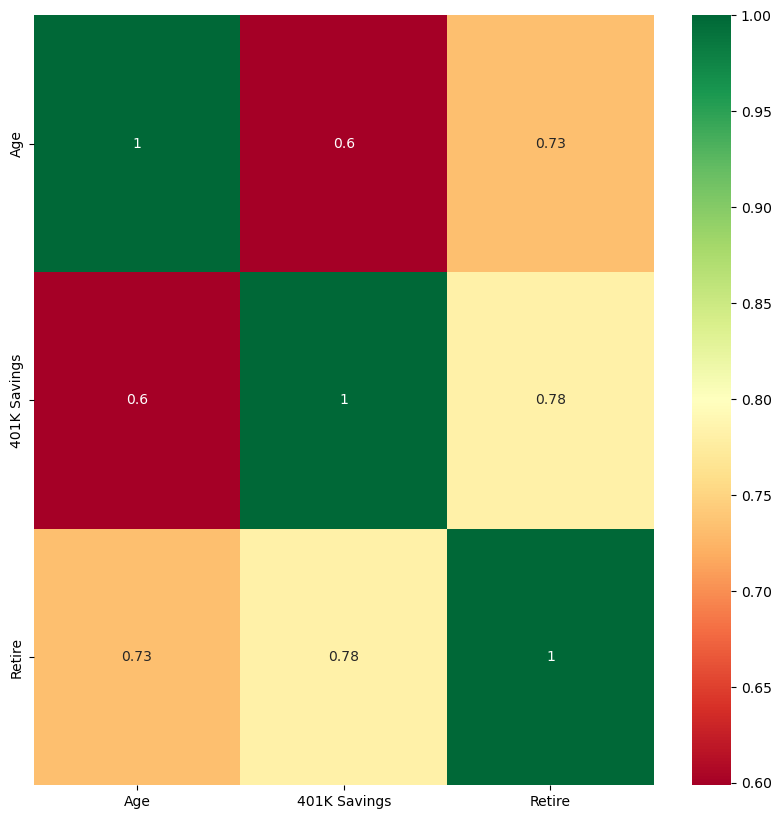

In [10]:
corrMatrix = data.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(corrMatrix,cmap="RdYlGn", annot=True)
plt.show()

### Пропущенные значения

In [11]:
data.isnull().mean()*100

Age             4.4
401K Savings    3.2
Retire          0.0
dtype: float64

In [12]:
data['age_null'] = np.where(data['Age'].isnull(),1,0)
data.groupby(['Retire'])['age_null'].mean()

Retire
0    0.048
1    0.040
Name: age_null, dtype: float64

In [13]:
data['401K Savings_null'] = np.where(data['401K Savings'].isnull(),1,0)
data.groupby(['Retire'])['401K Savings_null'].mean()

Retire
0    0.028
1    0.036
Name: 401K Savings_null, dtype: float64

<Axes: xlabel='Age', ylabel='401K Savings'>

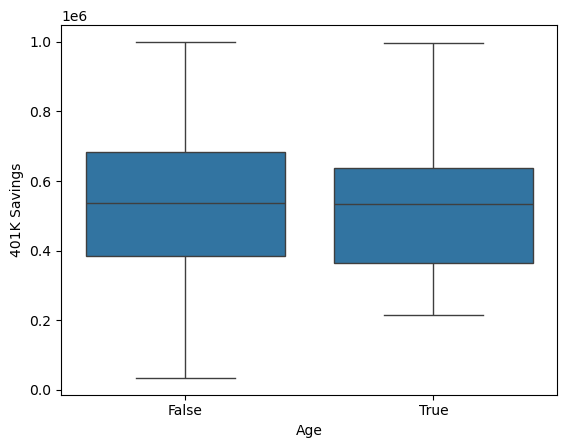

In [14]:
sns.boxplot(x=data["Age"].isnull(), y=data["401K Savings"])

<Axes: xlabel='401K Savings', ylabel='Age'>

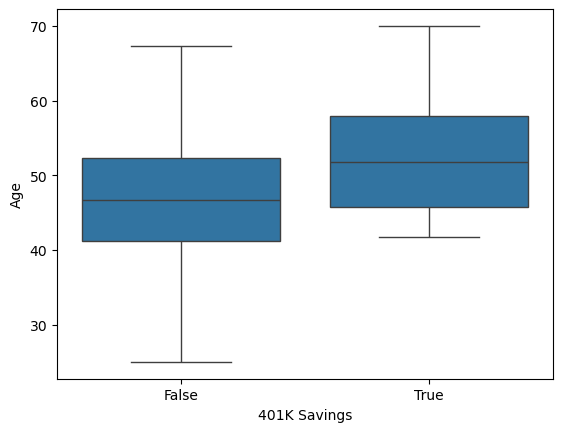

In [15]:
sns.boxplot(x=data["401K Savings"].isnull(), y=data["Age"])

In [16]:
data = data.drop(['401K Savings_null','age_null' ], axis=1)

В Age пропусков ≈ 4.4%, в 401K Savings ≈ 3.2%.


По графику — распределение накоплений почти не отличается → гипотеза о зависимости пропусков от 401k отвергается.
Можно предположить, что пропуски в этих признаках MCAR (случайные).


Пропуски в 401K Savings не случайные: они связаны с возрастом.
Скорее всего, данные MAR (Missing At Random): у более пожилых клиентов чаще нет информации по накоплениям.

Age: можно спокойно восстанавливать простыми методами (среднее, медиана, RandomSampleImputation и т.п.), потому что MСAR.

401K Savings: здесь нужно аккуратнее — лучше использовать методы, учитывающие зависимость от возраста (например, IterativeImputer, регрессия по Age, KNN-Imputer).

In [17]:
data.shape

(500, 3)

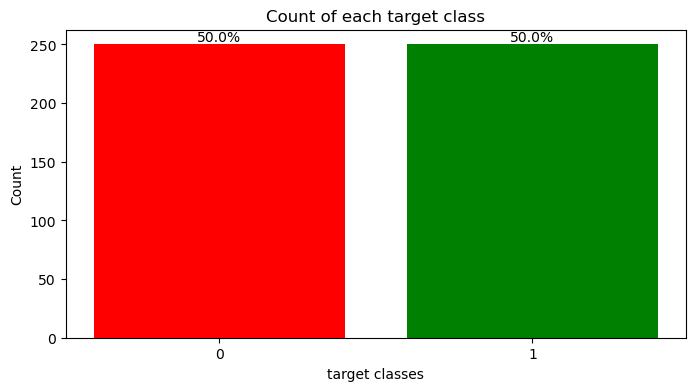

In [18]:
counts = data['Retire'].value_counts().sort_index()
total = counts.sum()
plt.figure(figsize=(8, 4))
bars = plt.bar(counts.index, counts.values, color=['red', 'green'])
plt.xticks(counts.index)
plt.xlabel('target classes')
plt.ylabel('Count')
plt.title('Count of each target class')

for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{percentage:.1f}%',
        ha='center',
        va='bottom' 
    )

plt.show()

Датасет сбалансированный</br>

В датасете категориальные пременные отсутсвуют, поэтому кодирование не требуется

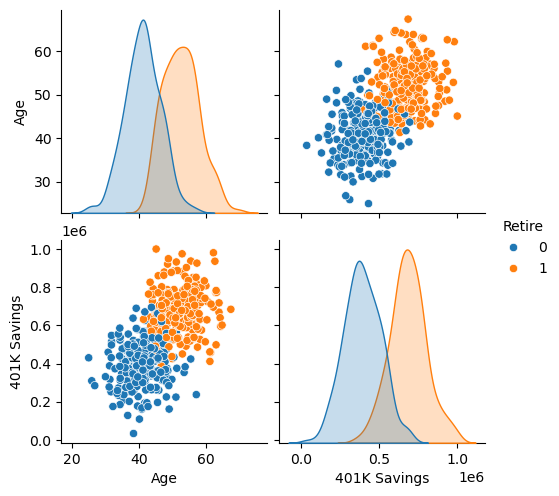

In [19]:
sns.pairplot(data, hue= 'Retire' , vars =['Age','401K Savings'])

График показывает положительную корреляцию: чем старше человек, тем больше у него сбережений, особенно среди тех, кто ушёл. 
Видно, что люди, которые ушли из банка, в среднем старше и имеют большие сбережения.

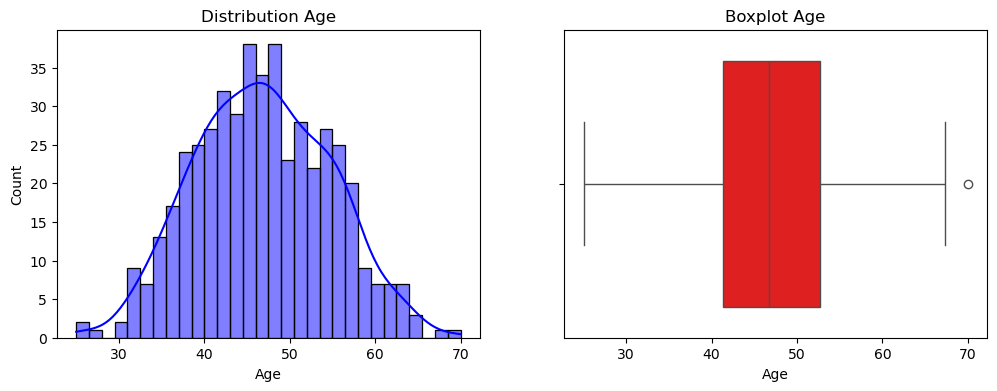

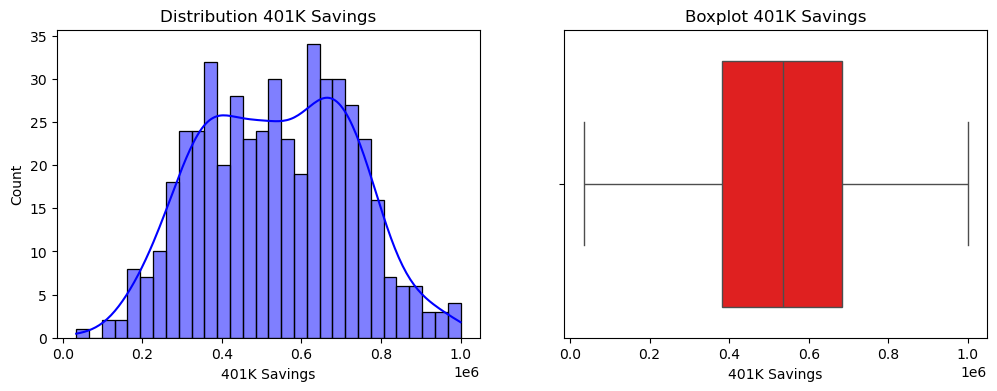

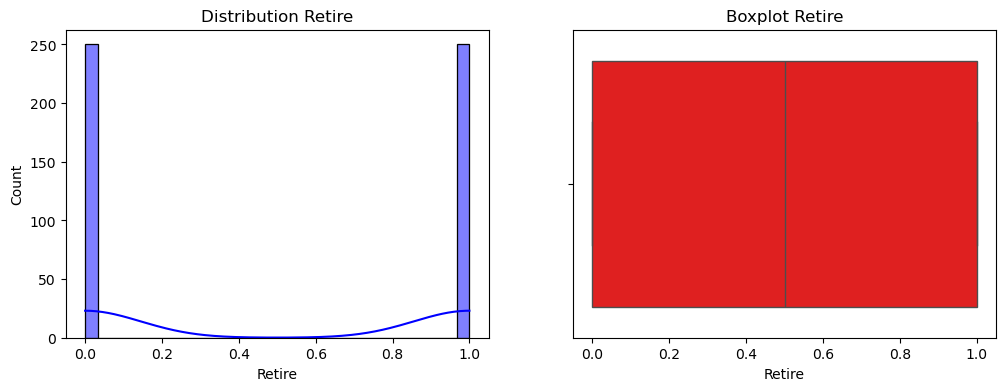

In [20]:
for col in data.columns:
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    sns.histplot(data[col], kde=True, color='blue', bins=30)
    plt.title(f'Distribution {col}')
    
    plt.subplot(1,2,2)
    sns.boxplot(x=data[col], color='red')
    plt.title(f'Boxplot {col}')
    
    plt.show()

Распределение близко к нормальному, будем использоваться стандартизацию и трансформацию переменных

In [21]:
bins = [25, 39, 54, 64, 100]
labels = ['25-39', '40-54', '55-64', '65+']
data['age_group'] = pd.cut(data['Age'], bins=bins, labels=labels, right=True)

age_distribution = data['age_group'].value_counts().sort_index()
print("Customer distribution by age:")
print(age_distribution)

retire_distribution = data.groupby('age_group')['Retire'].mean() * 100
print("\nPercentage of retiring customers by age group:")
print(retire_distribution)

Customer distribution by age:
age_group
25-39     80
40-54    300
55-64     92
65+        5
Name: count, dtype: int64

Percentage of retiring customers by age group:
age_group
25-39      0.000000
40-54     48.333333
55-64     97.826087
65+      100.000000
Name: Retire, dtype: float64


C:\Users\Сен Гван\AppData\Local\Temp\ipykernel_36960\3495939117.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  retire_distribution = data.groupby('age_group')['Retire'].mean() * 100


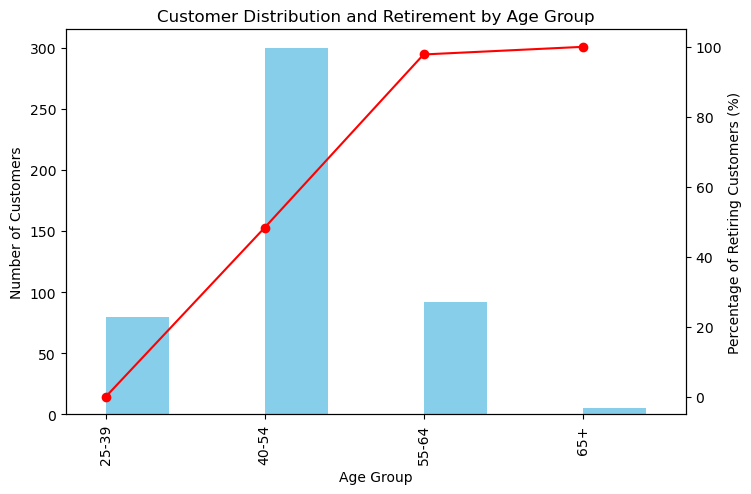

In [22]:
fig, ax1 = plt.subplots(figsize=(8,5))

age_distribution.plot(kind='bar', color='skyblue', ax=ax1, position=0, width=0.4)
ax1.set_ylabel('Number of Customers')
ax1.set_xlabel('Age Group')

ax2 = ax1.twinx()
retire_distribution.plot(kind='line', marker='o', color='red', ax=ax2)
ax2.set_ylabel('Percentage of Retiring Customers (%)')

plt.title('Customer Distribution and Retirement by Age Group')
plt.show()

Больший процент уходящий приходится на людей пенсионного и предпенсионного возраста

                    mean        median           min           max
age_group                                                         
25-39      375648.822292  380482.46690   33837.93215   638074.5123
40-54      538273.973599  536256.51110  109281.63450  1000000.0000
55-64      678952.148238  674958.68540  237410.94740   980549.6557
65+        630273.013825  620835.50285  595089.71060   684331.3390


C:\Users\Сен Гван\AppData\Local\Temp\ipykernel_36960\3208630982.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  savings_stats = data.groupby('age_group')['401K Savings'].agg(['mean', 'median', 'min', 'max'])
C:\Users\Сен Гван\AppData\Local\Temp\ipykernel_36960\3208630982.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_group', y='401K Savings', data=data, palette="pastel")


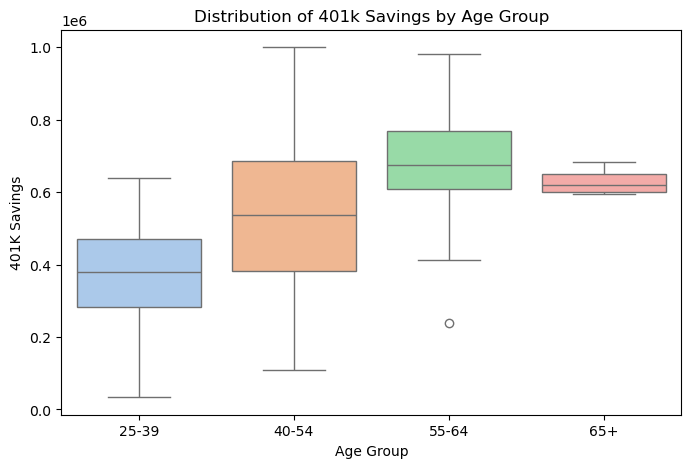

In [23]:
savings_stats = data.groupby('age_group')['401K Savings'].agg(['mean', 'median', 'min', 'max'])
print(savings_stats)

plt.figure(figsize=(8,5))
sns.boxplot(x='age_group', y='401K Savings', data=data, palette="pastel")
plt.title("Distribution of 401k Savings by Age Group")
plt.xlabel("Age Group")
plt.ylabel("401K Savings")
plt.show()

                           mean        median           min           max  \
age_group Retire                                                            
25-39     0       375648.822292  380482.46690   33837.93215   638074.5123   
          1                 NaN           NaN           NaN           NaN   
40-54     0       399480.199754  383248.63060  109281.63450   694815.9482   
          1       683909.694043  686070.79210  386341.79630  1000000.0000   
55-64     0       330718.253450  330718.25345  237410.94740   424025.5595   
          1       687145.886939  683098.82890  411502.14230   980549.6557   
65+       0                 NaN           NaN           NaN           NaN   
          1       630273.013825  620835.50285  595089.71060   684331.3390   

                  count  
age_group Retire         
25-39     0          80  
          1           0  
40-54     0         149  
          1         142  
55-64     0           2  
          1          85  
65+       0          

C:\Users\Сен Гван\AppData\Local\Temp\ipykernel_36960\1593902560.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  savings_retire_stats = data.groupby(['age_group', 'Retire'])['401K Savings'].agg(['mean', 'median', 'min', 'max', 'count'])


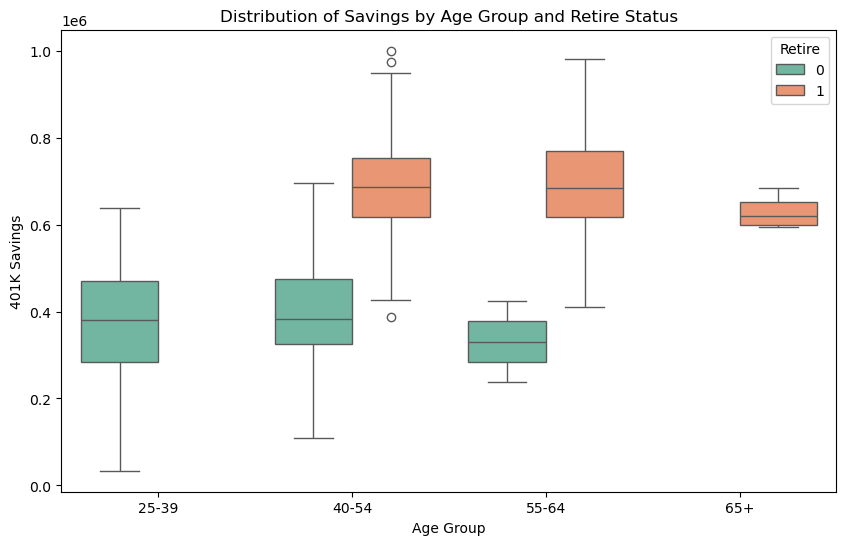

In [24]:
savings_retire_stats = data.groupby(['age_group', 'Retire'])['401K Savings'].agg(['mean', 'median', 'min', 'max', 'count'])
print(savings_retire_stats)

plt.figure(figsize=(10,6))
sns.boxplot(x='age_group', y='401K Savings', hue='Retire', data=data, palette="Set2")
plt.title("Distribution of Savings by Age Group and Retire Status")
plt.xlabel("Age Group")
plt.ylabel("401K Savings")
plt.legend(title="Retire")
plt.show()

1. люди в большими накоплениями чаще уходят из банка
2. основная возрастная группа уходящих примерно 50 и старше
3. люди старше 55 в основном уходят на пенсию, а люди меньше 40 держат деньги в банке 

### Conclusion



В данном датасете присутствуют всего 2 значимые независимые переменны. Проблема классификации бинарная(предсказание уйдет ли человек с банка или нет). 
Категориальные переменные отсутсвуют, остальные переменные продолжительные.Датасет сбалансирован.

В датасете имеются пропущенные значения. В ходе анализа выяснилось, что природа пропущенных значений у переменной "Age" - MCAR, поэтому можно заменить данные самыми простыми способами среднее, медиана, RandomSampleImputation....
У переменной '401K Savings' - MAR и она во многом зависит от переменной Age,следовательно, замену следует проводить болле сложными методами.

Деление людей на группые показывает, что люди ушедшие чаще пенсионного и предпенсионного возраста. Они имеют большие накопления и уходят на пенсию, люди с меньшеими накоплениями остаются в банке.


Распределение ппеременных ближе к нормальному, рассмотрим 2 метода трансформации и 2 метода масштабирования.
Данный датасет не требует отбора переменных. Для тренировки используем: Logistic regression, Decision tree, RandomForest, K-nn

## Инженерия переменных

In [25]:
data = data.drop(['age_group'], axis=1)

In [26]:
data_for_engin = data.copy()

In [27]:
data_for_engin.shape

(500, 3)

### Пропущенные значения

In [28]:
data_for_engin.isnull().mean()

Age             0.044
401K Savings    0.032
Retire          0.000
dtype: float64

In [29]:
X_train,X_test, y_train, y_test  =train_test_split(
    data_for_engin.drop(['Retire'], axis=1),
    data_for_engin['Retire'], 
    random_state = 0,
    test_size=0.3
)

In [30]:
X_train_Random, X_test_Random = imputation_function(RandomSampleImputer(random_state=0), X_train,X_test)

In [31]:
X_train_Random.isna().mean()

Age             0.0
401K Savings    0.0
dtype: float64

In [32]:
#RandomSample
classific_model(LogisticRegression(random_state=0), X_train_Random, y_train,X_test_Random, y_test)

Train dataset: 92.57%
Test dataset: 93.33%
Train Set roc-auc:0.9802941176470588
Test Set roc-auc:0.9848214285714286


In [33]:
classific_model(DecisionTreeClassifier(random_state=0), X_train_Random, y_train,X_test_Random, y_test)

Train dataset: 100.0%
Test dataset: 92.67%
Train Set roc-auc:1.0
Test Set roc-auc:0.9267857142857143


In [34]:
# MEAN
X_train_mean, X_test_mean = imputation_function(MeanMedianImputer(imputation_method='mean'), X_train,X_test)

In [35]:
classific_model(LogisticRegression(random_state=0), X_train_mean, y_train,X_test_mean, y_test)

Train dataset: 94.0%
Test dataset: 94.0%
Train Set roc-auc:0.987516339869281
Test Set roc-auc:0.9898214285714286


In [36]:
classific_model(DecisionTreeClassifier(random_state=0), X_train_mean, y_train,X_test_mean, y_test)

Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [37]:
# MEDIAN
X_train_median, X_test_median = imputation_function(MeanMedianImputer(imputation_method='median'), X_train,X_test)

In [38]:
classific_model(LogisticRegression(random_state=0), X_train_median, y_train,X_test_median, y_test)

Train dataset: 94.0%
Test dataset: 94.0%
Train Set roc-auc:0.9871895424836601
Test Set roc-auc:0.9896428571428572


In [39]:
classific_model(DecisionTreeClassifier(random_state=0), X_train_median, y_train,X_test_median, y_test)

Train dataset: 100.0%
Test dataset: 93.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9330357142857144


In [40]:
# K-nn for 401K
imputer = ColumnTransformer(transformers=[
    ("age_median", SimpleImputer(strategy="mean"), ["Age"]),
    ("savings_knn", KNNImputer(n_neighbors=5), ["401K Savings"])
], remainder="passthrough")

imputer.fit(X_train)

X_train_imp = pd.DataFrame(imputer.transform(X_train), columns=imputer.get_feature_names_out())
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=imputer.get_feature_names_out())

In [41]:
classific_model(LogisticRegression(random_state=0), X_train_imp, y_train,X_test_imp, y_test)

Train dataset: 94.0%
Test dataset: 94.0%
Train Set roc-auc:0.987516339869281
Test Set roc-auc:0.9898214285714286


In [42]:
classific_model(DecisionTreeClassifier(random_state=0), X_train_imp, y_train,X_test_imp, y_test)

Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [43]:
imputer = ColumnTransformer(transformers=[
    ("age_median", SimpleImputer(strategy="mean"), ["Age"]),
    ("savings_iter", IterativeImputer(random_state=0), ["401K Savings"])
], remainder="passthrough")

imputer.fit(X_train)

X_train_IT = pd.DataFrame(imputer.transform(X_train), columns=imputer.get_feature_names_out(), index=X_train.index)
X_test_IT = pd.DataFrame(imputer.transform(X_test), columns=imputer.get_feature_names_out(), index=X_test.index)


In [44]:
classific_model(LogisticRegression(random_state=0), X_train_IT, y_train,X_test_IT, y_test)

Train dataset: 94.0%
Test dataset: 94.0%
Train Set roc-auc:0.987516339869281
Test Set roc-auc:0.9898214285714286


In [45]:
classific_model(DecisionTreeClassifier(random_state=0), X_train_IT, y_train,X_test_IT, y_test)

Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [46]:
# Переменная для улучшения связи
data_for_engin["SavingsPerAge"] = data_for_engin["401K Savings"] / data_for_engin["Age"]

In [47]:
X_train,X_test, y_train, y_test  =train_test_split(
    data_for_engin.drop(['Retire'], axis=1),
    data_for_engin['Retire'], 
    random_state = 0,
    test_size=0.3
)

In [48]:
X_train_mean, X_test_mean = imputation_function(MeanMedianImputer(imputation_method='mean'), X_train,X_test)

In [49]:
classific_model(LogisticRegression(random_state=0), X_train_mean, y_train,X_test_mean, y_test)

Train dataset: 94.29%
Test dataset: 94.0%
Train Set roc-auc:0.9882352941176471
Test Set roc-auc:0.984107142857143


C:\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [50]:
classific_model(DecisionTreeClassifier(random_state=0), X_train_mean, y_train,X_test_mean, y_test)

Train dataset: 100.0%
Test dataset: 96.0%
Train Set roc-auc:1.0
Test Set roc-auc:0.9598214285714286


Заметное улучшение более сложными методам не наблюдается, поэтому используем замену пустых значений на mean

Переменную "SavingsPerAge" создал для улучшения связи меджу переменными, как можно заметить модель улучшает показатели

### Трансформация

In [51]:
TransforData = data.copy()
data.shape

(500, 3)

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    TransforData.drop(['Retire'], axis=1),
    TransforData['Retire'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((350, 2), (150, 2))

In [53]:
X_train, X_test = imputation_function(MeanMedianImputer(imputation_method='mean'), X_train,X_test)

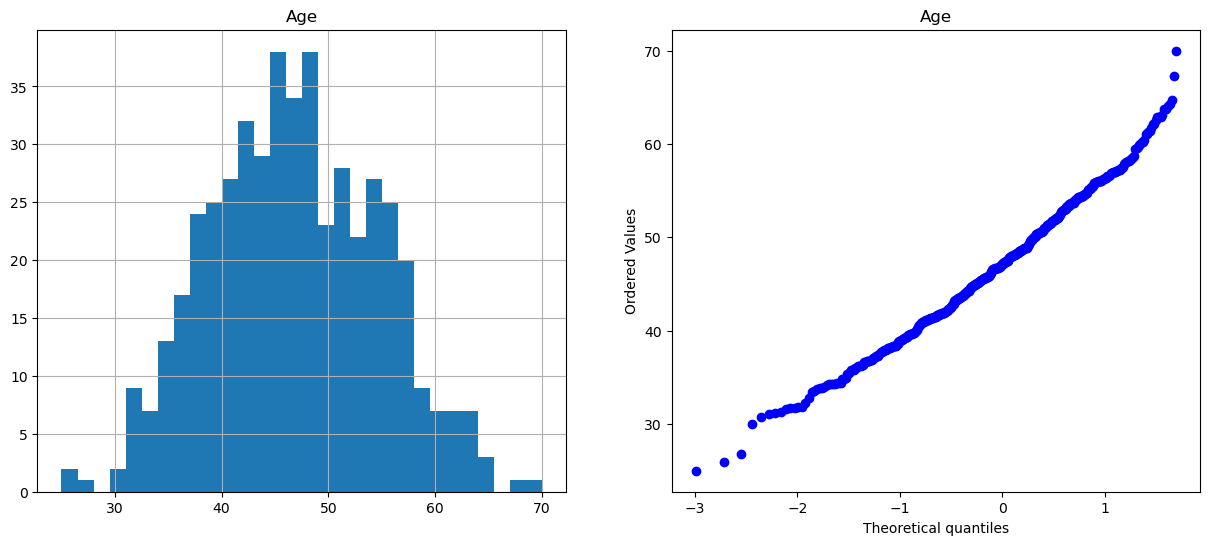

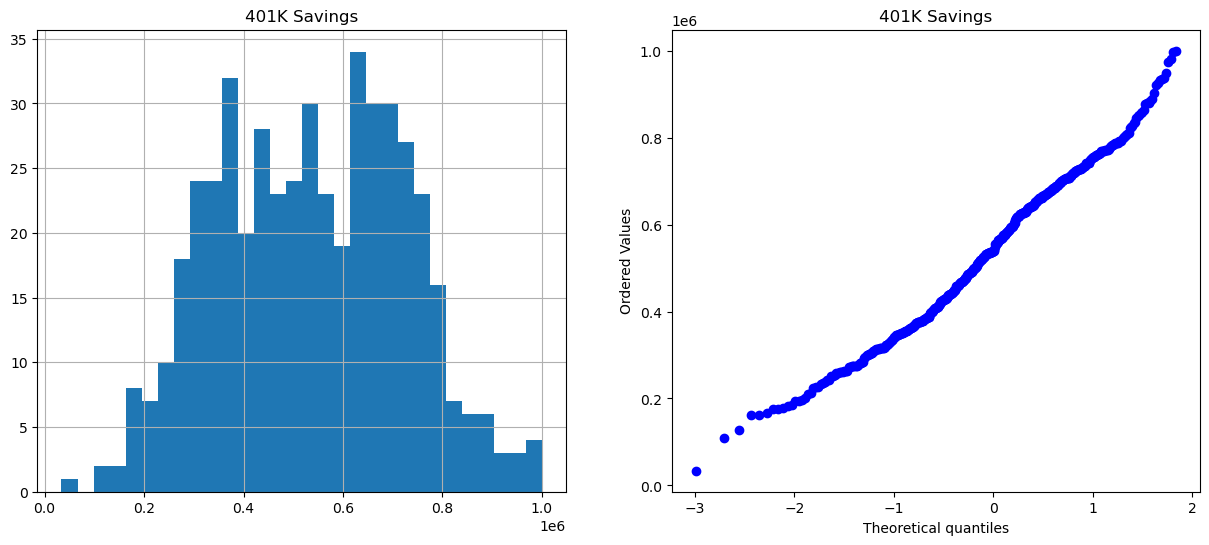

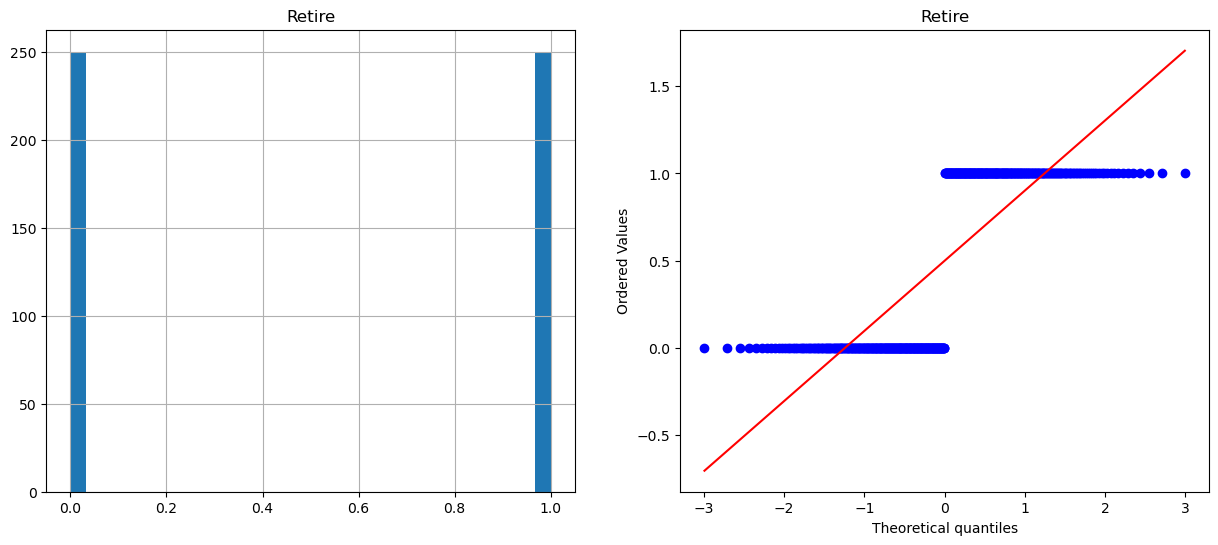

In [54]:
for var in data:
    diagnostic_plots(TransforData, var)

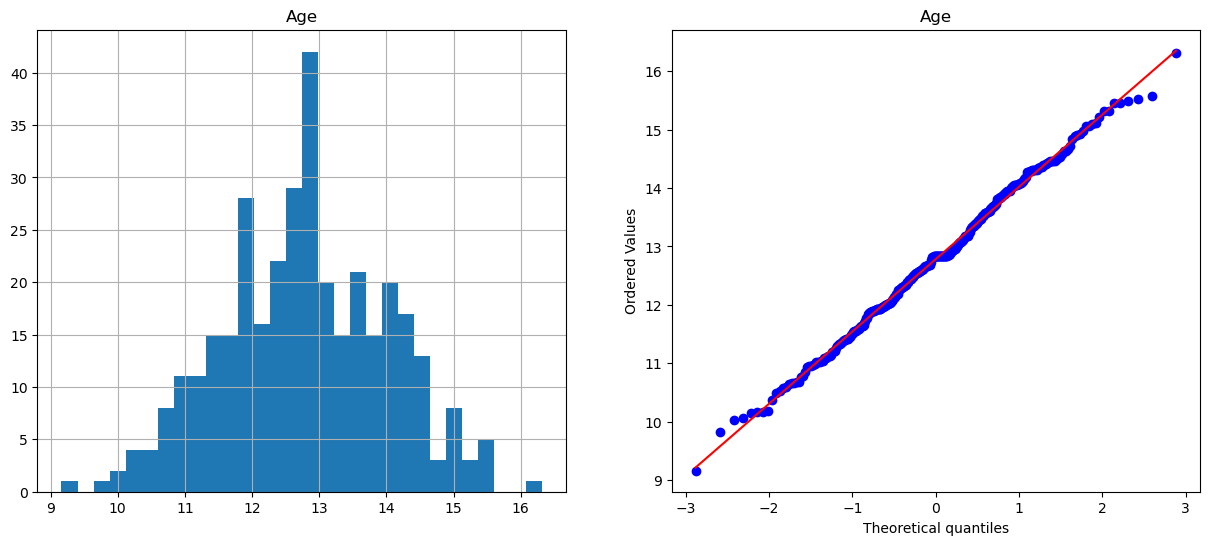

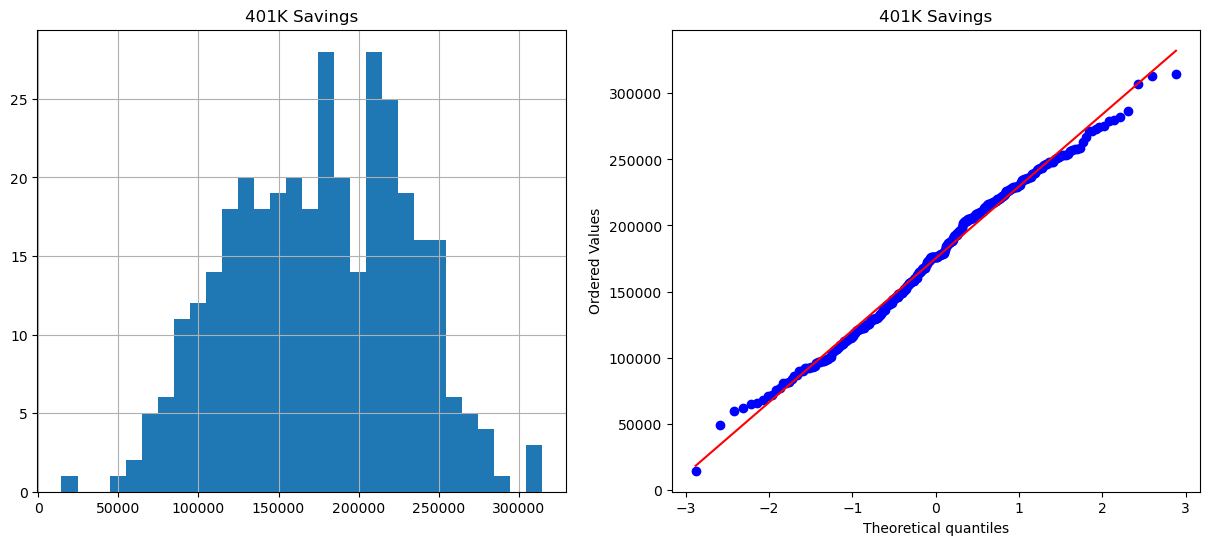

 Logistic Regression:
Train dataset: 94.29%
Test dataset: 94.0%
Train Set roc-auc:0.9871241830065359
Test Set roc-auc:0.9898214285714285

 Decision Tree:
Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [55]:
## Yeo-Jojhson
transformationfordata(vt.YeoJohnsonTransformer())

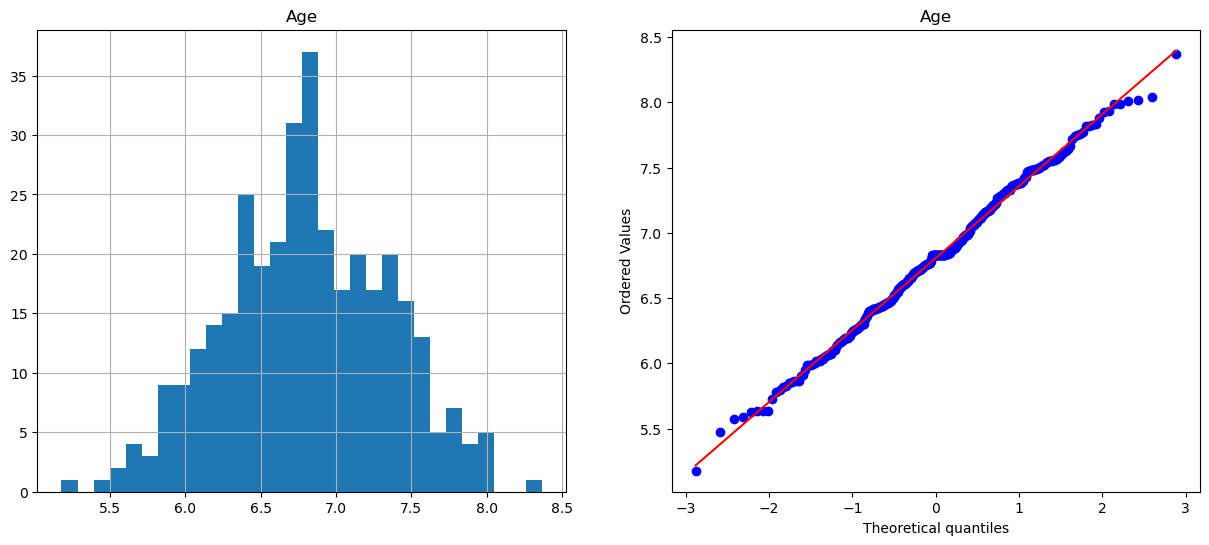

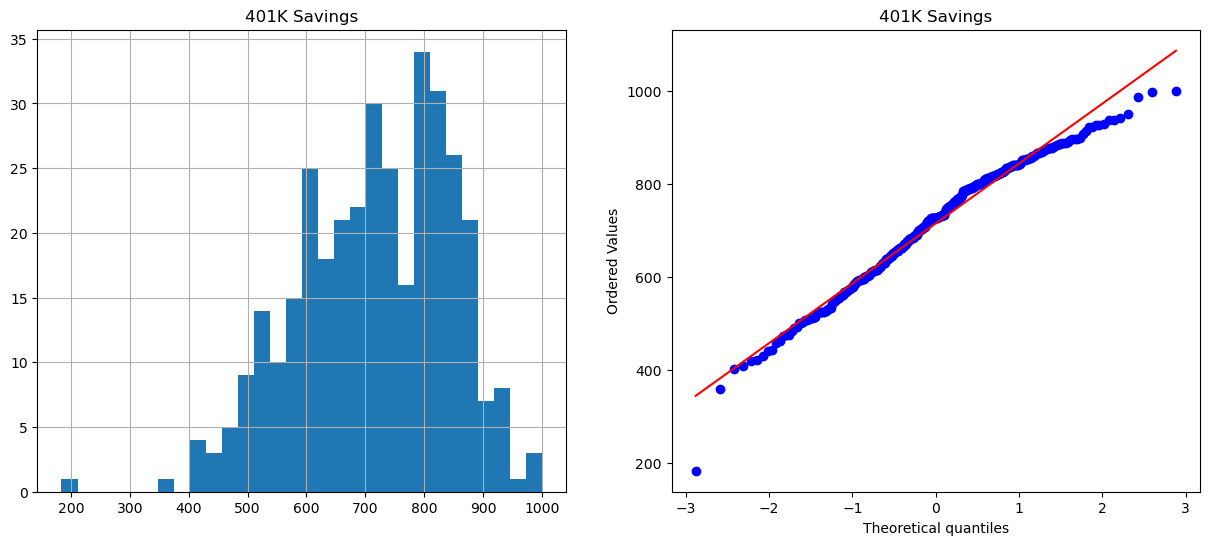

 Logistic Regression:
Train dataset: 94.0%
Test dataset: 95.33%
Train Set roc-auc:0.9862091503267975
Test Set roc-auc:0.9901785714285715

 Decision Tree:
Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [56]:
## Exponential
transformationfordata(vt.PowerTransformer())

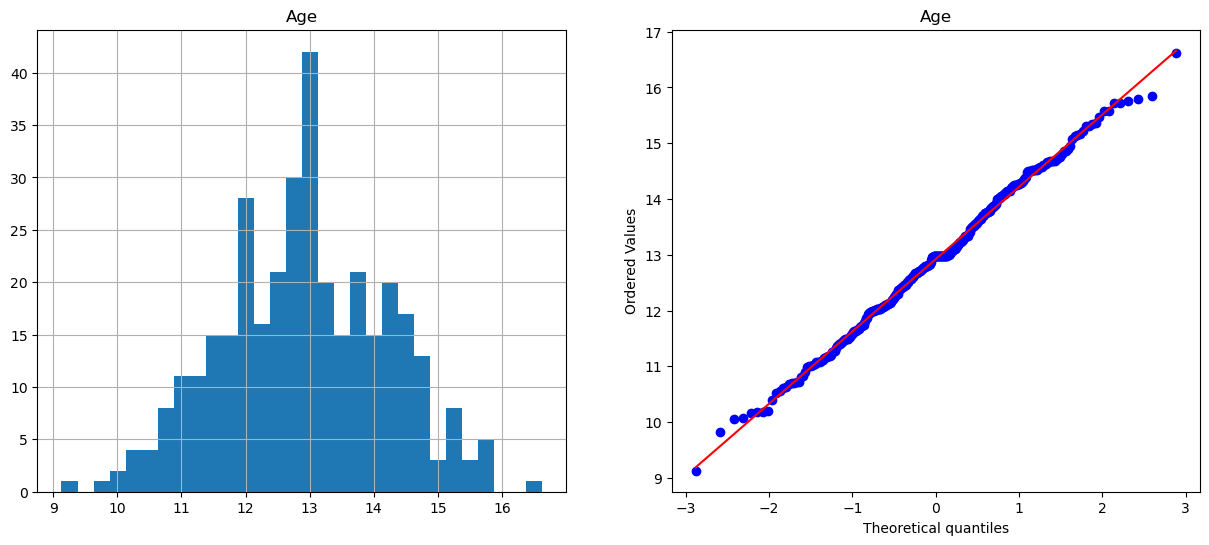

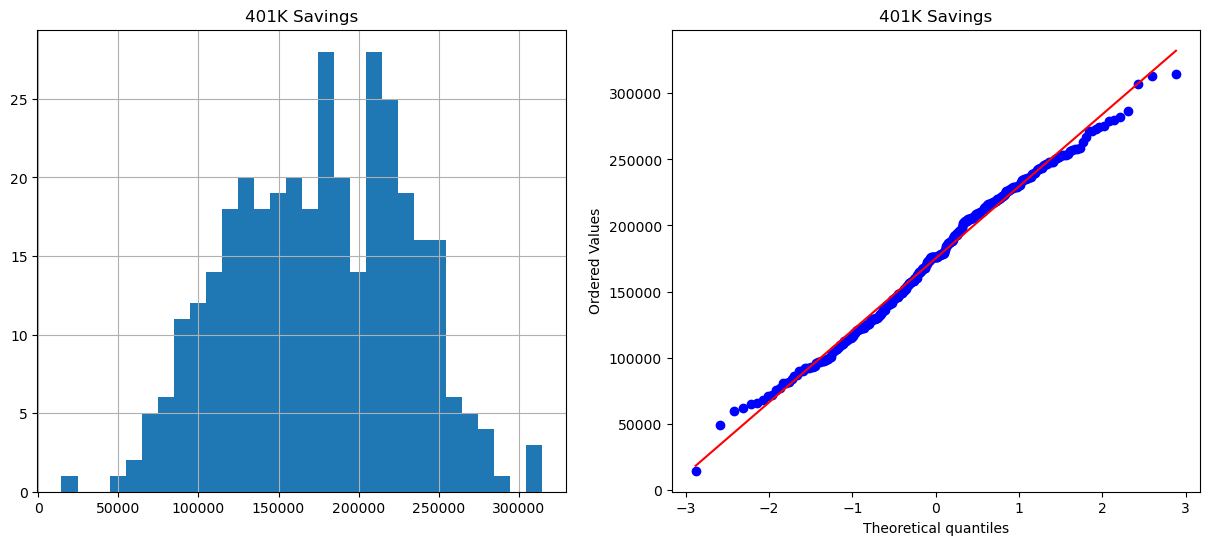

 Logistic Regression:
Train dataset: 94.29%
Test dataset: 94.0%
Train Set roc-auc:0.9870915032679738
Test Set roc-auc:0.9898214285714285

 Decision Tree:
Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [57]:
## BoxCox
transformationfordata(vt.BoxCoxTransformer())

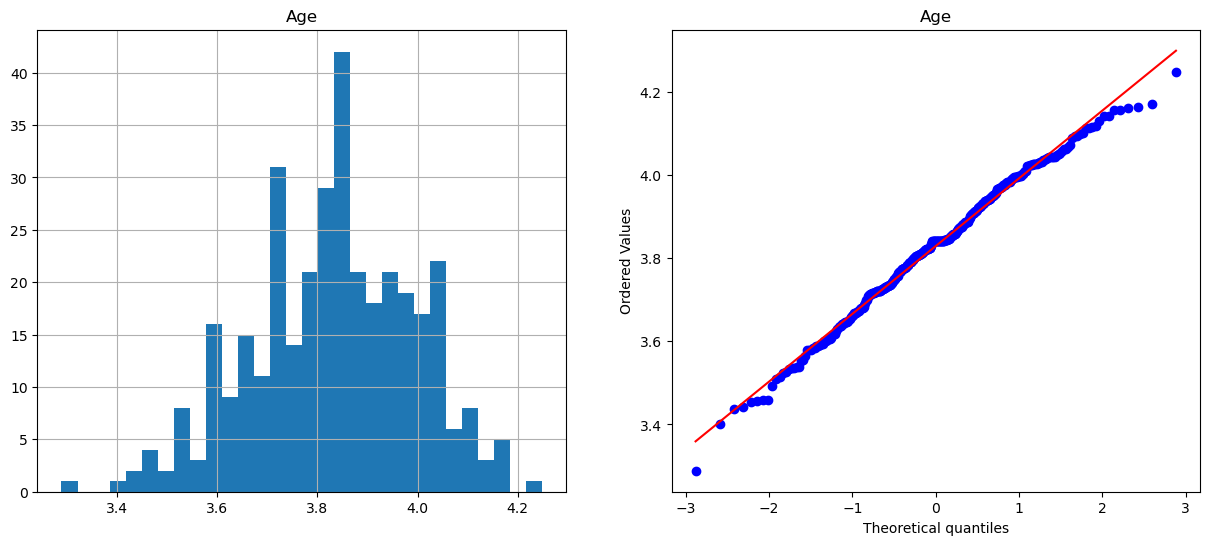

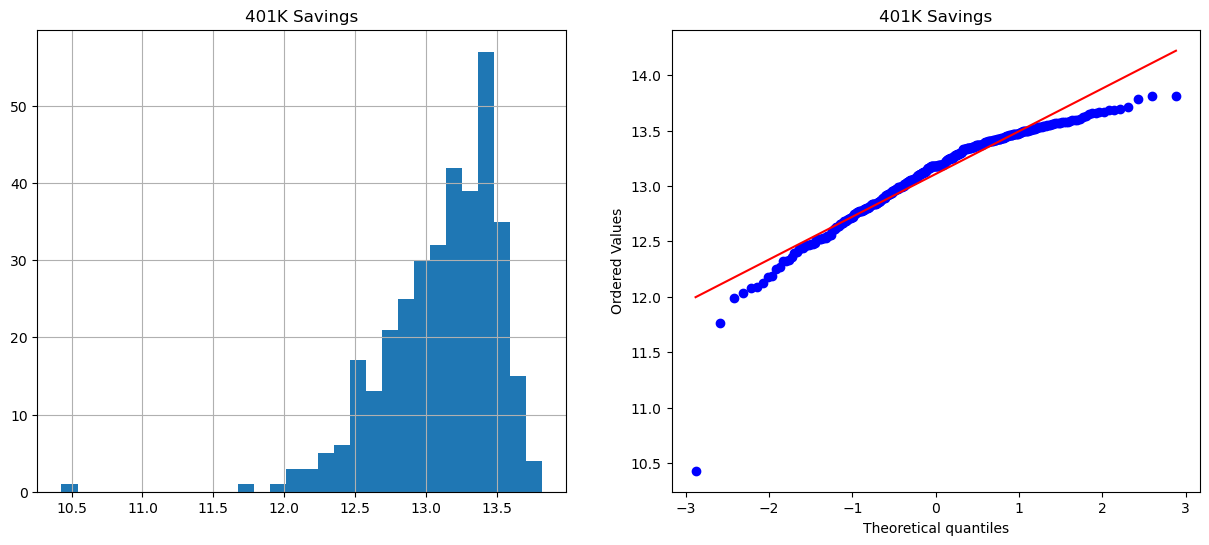

 Logistic Regression:
Train dataset: 93.14%
Test dataset: 95.33%
Train Set roc-auc:0.9819934640522876
Test Set roc-auc:0.9901785714285715

 Decision Tree:
Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [58]:
## LogTrans
transformationfordata(vt.LogTransformer())

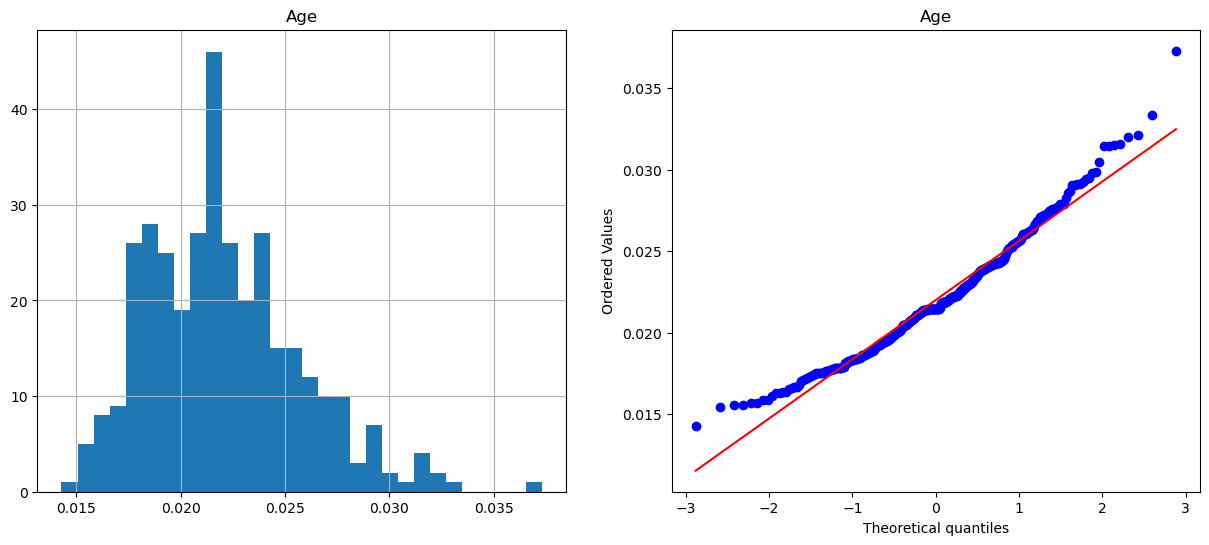

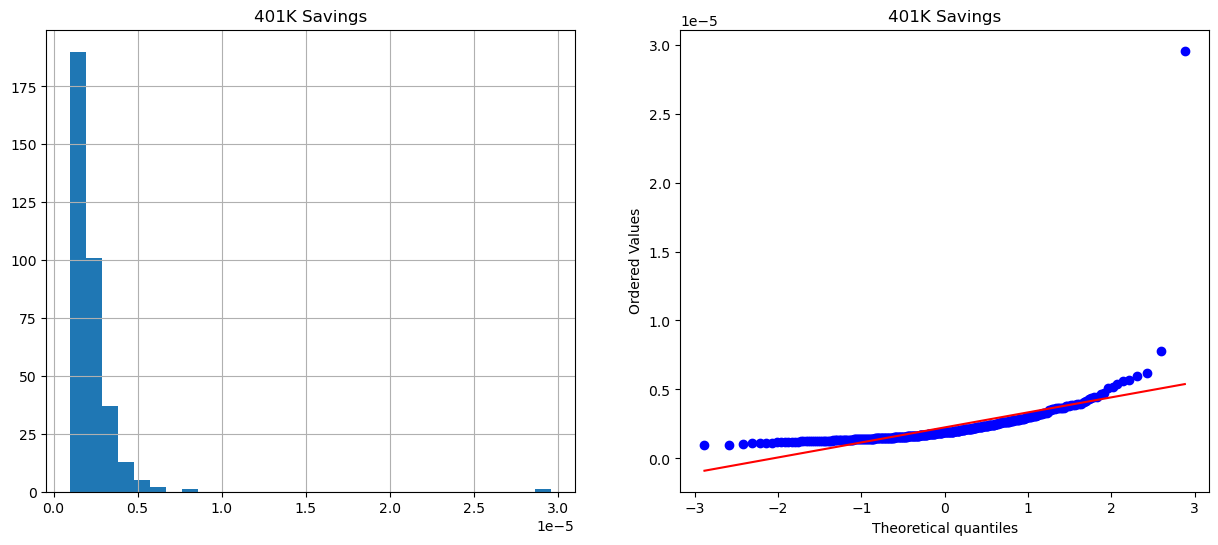

 Logistic Regression:
Train dataset: 51.43%
Test dataset: 46.67%
Train Set roc-auc:0.933562091503268
Test Set roc-auc:0.9260714285714285

 Decision Tree:
Train dataset: 99.43%
Test dataset: 92.0%
Train Set roc-auc:0.9999346405228758
Test Set roc-auc:0.9207142857142857


In [59]:
## Reciprocal
transformationfordata(vt.ReciprocalTransformer())

Трансформация не представялется обходимым, так как не происходит улучшение распределение и ухудшает метрики

### Масштабирование

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    TransforData.drop(['Retire'], axis=1),
    TransforData['Retire'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((350, 2), (150, 2))

In [61]:
Scalerfordata(RobustScaler(), X_train, X_test, y_train, y_test)

 Logistic Regression:
Train dataset: 94.0%
Test dataset: 94.0%
Train Set roc-auc:0.9874183006535948
Test Set roc-auc:0.99

 Decision Tree:
Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [62]:
Scalerfordata(StandardScaler(), X_train, X_test, y_train, y_test)

 Logistic Regression:
Train dataset: 94.29%
Test dataset: 94.0%
Train Set roc-auc:0.9873202614379085
Test Set roc-auc:0.9898214285714285

 Decision Tree:
Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [63]:
Scalerfordata(MinMaxScaler(), X_train, X_test, y_train, y_test)

 Logistic Regression:
Train dataset: 94.29%
Test dataset: 94.0%
Train Set roc-auc:0.9866013071895424
Test Set roc-auc:0.9901785714285715

 Decision Tree:
Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


Вывод по инженерии переменных:
- Лучшим методом замены показывает Mean
- Масштабирование переменных и трансформация не улучшают показатели
- Для большей связи используем перменную "SavingsPerAge"

## Шаг пятый. Построение модели

### Baseline model

In [64]:
data_for_engin["SavingsPerAge"] = data_for_engin["401K Savings"] / data_for_engin["Age"]

In [65]:
X_train,X_test, y_train, y_test  =train_test_split(
    data_for_engin.drop(['Retire',"SavingsPerAge" ], axis=1),
    data_for_engin['Retire'], 
    random_state = 0,
    test_size=0.3
)
X_train.shape, X_test.shape

((350, 2), (150, 2))

In [66]:
# zero hypotheses
y_pred_base = np.zeros((len(y_test)))
compare = y_pred_base == y_test
acc_base = sum(compare) / len(compare)
print('Base Line Test Accuracy = ', acc_base)

Base Line Test Accuracy =  0.4666666666666667


In [67]:
baseline = Pipeline(steps = [
    ('imputer', MeanMedianImputer(imputation_method='mean')),
    ('scaler', StandardScaler()),
    ('Logit', LogisticRegression(random_state=0))
])

In [68]:
baseline.fit(X_train, y_train)

Pipeline(steps=[('imputer', MeanMedianImputer(imputation_method='mean')),
                ('scaler', StandardScaler()),
                ('Logit', LogisticRegression(random_state=0))])

In [69]:
X_train_proba, X_test_proba,X_train_pred,X_test_pred, predict_time = Metrics_char(baseline, X_train, X_test)

 Время предсказания: 0.002 секунд
Train Set
LogisticRegression accuracy: 0.9429
Test Set
LogisticRegression accuracy: 0.9400

Train Set
LogisticRegression ROC-AUC: 0.9873
Test Set
LogisticRegression ROC-AUC: 0.9898
Train Set
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       180
           1       0.94      0.95      0.94       170

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350

Test Set
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        70
           1       0.96      0.93      0.94        80

    accuracy                           0.94       150
   macro avg       0.94      0.94      0.94       150
weighted avg       0.94      0.94      0.94       150



In [70]:
results = pd.DataFrame(columns=['F1', 'Accuracy', 'ROC AUC', 'Predict time']).T

In [71]:
results = metrics_gridsearch ("baseline_model", y_test, y_train, X_test_pred, X_test_proba[:, 1], X_train_pred, X_train_proba[:, 1],predict_time, results)

In [72]:
results

,baseline_model_test,baseline_model_train
F1,0.942700,0.941500
Accuracy,0.940000,0.942900
ROC AUC,0.989800,0.987300
Predict time,0.001505,0.001505


### Logistic regression

In [73]:
X_train,X_test, y_train, y_test = train_test_split(
    data_for_engin.drop(['Retire'], axis=1),
    data_for_engin['Retire'], 
    random_state = 0,
    test_size=0.3
)
X_train.shape, X_test.shape

((350, 3), (150, 3))

In [74]:
Logitpipe = Pipeline(steps = [
    ('imputer', MeanMedianImputer(imputation_method='mean')),
    ('transformer', vt.BoxCoxTransformer()),
    ('scaler', StandardScaler()),
    ('Logit', LogisticRegression(random_state=0))
])

In [75]:
Logit_param_grid = {
    'transformer':[vt.BoxCoxTransformer(),vt.YeoJohnsonTransformer()],
    'scaler': [StandardScaler(), MinMaxScaler()],
    'Logit__C': [0.05, 0.1,0.2],
    'Logit__max_iter': [5,7,10]}

In [76]:
Logit_grid_search = GridSearchCV(estimator=Logitpipe, param_grid=Logit_param_grid, cv=5, n_jobs=-1, scoring='accuracy', error_score='raise')

In [77]:
LOGIT_MODEL = Logit_grid_search.fit(X_train, y_train)

C:\anaconda3\envs\KV-AI-JLR-12\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [78]:
LOGIT_MODEL.best_params_

{'Logit__C': 0.1,
 'Logit__max_iter': 5,
 'scaler': StandardScaler(),
 'transformer': BoxCoxTransformer()}

In [79]:
X_train_proba, X_test_proba,X_train_pred,X_test_pred, predict_time = Metrics_char(LOGIT_MODEL, X_train, X_test)

 Время предсказания: 0.003 секунд
Train Set
LogisticRegression accuracy: 0.9400
Test Set
LogisticRegression accuracy: 0.9467

Train Set
LogisticRegression ROC-AUC: 0.9857
Test Set
LogisticRegression ROC-AUC: 0.9918
Train Set
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       180
           1       0.93      0.95      0.94       170

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350

Test Set
              precision    recall  f1-score   support

           0       0.93      0.96      0.94        70
           1       0.96      0.94      0.95        80

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



In [80]:
results = metrics_gridsearch ("Logit_model", y_test, y_train, X_test_pred, X_test_proba[:, 1], X_train_pred, X_train_proba[:, 1],predict_time, results)

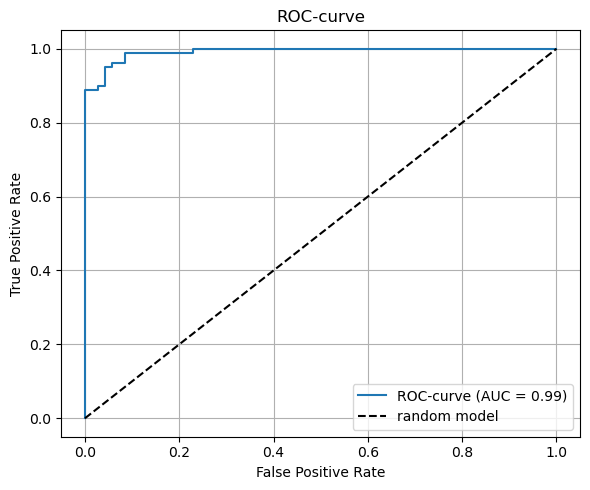

In [81]:
ROC_curve(y_test,X_test_proba[:, 1])

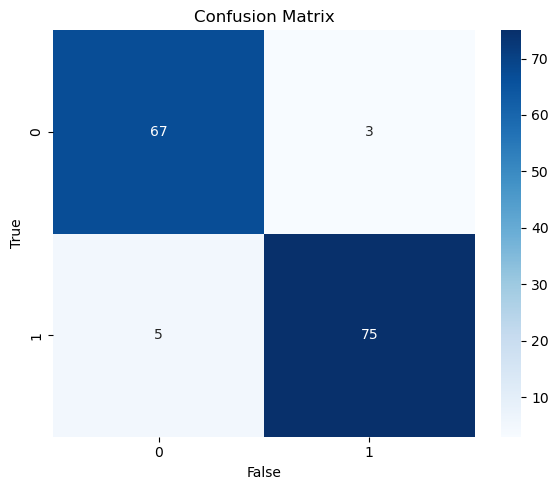

In [82]:
plot_custom_confusion_matrix(y_test, X_test_pred,labels=[0, 1], normalize=False,)

### Decision Tree

In [83]:
X_train,X_test, y_train, y_test  =train_test_split(
    data_for_engin.drop(['Retire',"SavingsPerAge"], axis=1),
    data_for_engin['Retire'], 
    random_state = 0,
    test_size=0.3
)
X_train.shape, X_test.shape

((350, 2), (150, 2))

In [84]:
DT_pipeline = Pipeline(steps=[
    ('imputer', MeanMedianImputer(imputation_method='mean')),
    #('transformer', vt.YeoJohnsonTransformer()),
    ('model', DecisionTreeClassifier(random_state=0))
])

In [85]:
DT_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', MeanMedianImputer(imputation_method='mean')),
                ('model', DecisionTreeClassifier(random_state=0))])

In [86]:
X_train_proba, X_test_proba,X_train_pred,X_test_pred, predict_time = Metrics_char(DT_pipeline, X_train, X_test)

 Время предсказания: 0.001 секунд
Train Set
DecisionTreeClassifier accuracy: 1.0000
Test Set
DecisionTreeClassifier accuracy: 0.9533

Train Set
DecisionTreeClassifier ROC-AUC: 1.0000
Test Set
DecisionTreeClassifier ROC-AUC: 0.9536
Train Set
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       180
           1       1.00      1.00      1.00       170

    accuracy                           1.00       350
   macro avg       1.00      1.00      1.00       350
weighted avg       1.00      1.00      1.00       350

Test Set
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        70
           1       0.96      0.95      0.96        80

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



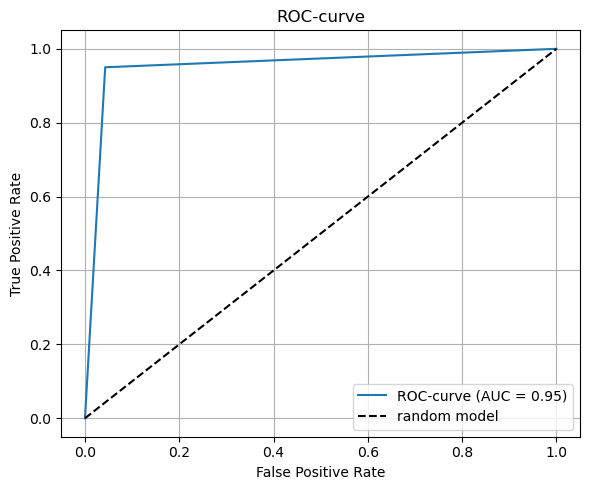

In [87]:
ROC_curve(y_test,X_test_proba[:, 1])

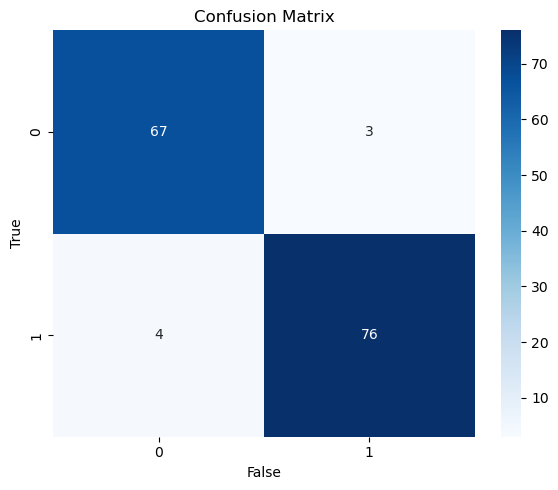

In [88]:
plot_custom_confusion_matrix(y_test, X_test_pred,labels=[0, 1], normalize=False)

In [89]:
# Настройка гиперпараметров
DT_param_grid = {
    'model__max_depth': [4,5],
    'model__min_samples_leaf': [6,7,8],
    'model__min_samples_split': [5,6]}

In [90]:
DT_grid_search = GridSearchCV(estimator=DT_pipeline, param_grid=DT_param_grid, cv=5, n_jobs=-1, scoring='accuracy', error_score='raise')

In [91]:
DT_MODEL = DT_grid_search.fit(X_train, y_train)

In [92]:
DT_MODEL.best_params_

{'model__max_depth': 4,
 'model__min_samples_leaf': 6,
 'model__min_samples_split': 5}

In [93]:
X_train_proba, X_test_proba,X_train_pred,X_test_pred, predict_time = Metrics_char(DT_MODEL, X_train, X_test)

 Время предсказания: 0.001 секунд
Train Set
DecisionTreeClassifier accuracy: 0.9543
Test Set
DecisionTreeClassifier accuracy: 0.9533

Train Set
DecisionTreeClassifier ROC-AUC: 0.9922
Test Set
DecisionTreeClassifier ROC-AUC: 0.9851
Train Set
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       180
           1       0.96      0.94      0.95       170

    accuracy                           0.95       350
   macro avg       0.95      0.95      0.95       350
weighted avg       0.95      0.95      0.95       350

Test Set
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        70
           1       0.97      0.94      0.96        80

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



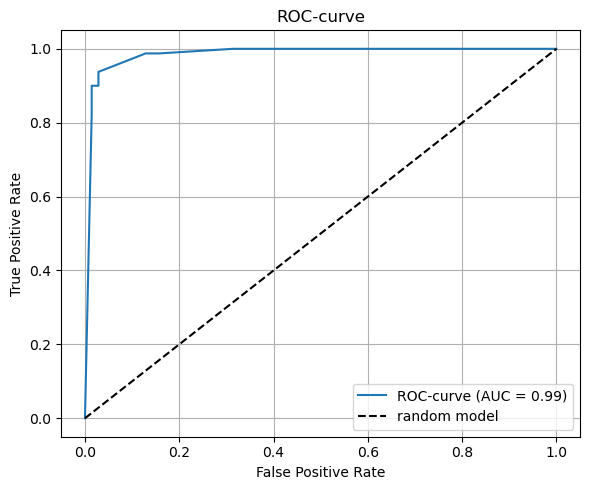

In [94]:
ROC_curve(y_test,X_test_proba[:, 1])

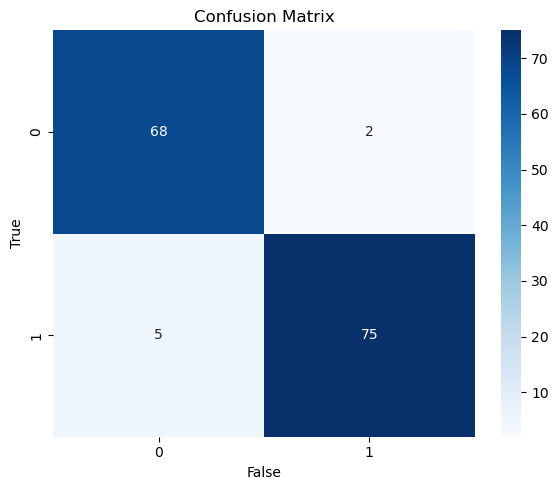

In [95]:
plot_custom_confusion_matrix(y_test, X_test_pred,labels=[0, 1], normalize=False)

In [96]:
results = metrics_gridsearch ("DecisionTree_model", y_test, y_train, X_test_pred, X_test_proba[:, 1], X_train_pred, X_train_proba[:, 1],predict_time, results)

In [97]:
results

,baseline_model_test,baseline_model_train,Logit_model_test,Logit_model_train,DecisionTree_model_test,DecisionTree_model_train
F1,0.942700,0.941500,0.9494,0.9388,0.9554,0.9524
Accuracy,0.940000,0.942900,0.9467,0.9400,0.9533,0.9543
ROC AUC,0.989800,0.987300,0.9918,0.9857,0.9851,0.9922
Predict time,0.001505,0.001505,0.0030,0.0030,0.0010,0.0010


### K-nn model

In [98]:
X_train,X_test, y_train, y_test  =train_test_split(
    data_for_engin.drop(['Retire',"SavingsPerAge"], axis=1),
    data_for_engin['Retire'], 
    random_state = 0,
    test_size=0.3
)
X_train.shape, X_test.shape

((350, 2), (150, 2))

In [99]:
KNN_pipeline = Pipeline(steps=[
    ('imputer', MeanMedianImputer(imputation_method='mean')),
    #('transformer', vt.YeoJohnsonTransformer()),
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=6))
])

In [100]:
KNN_pipeline.fit(X_train,y_train)

Pipeline(steps=[('imputer', MeanMedianImputer(imputation_method='mean')),
                ('scaler', StandardScaler()),
                ('model', KNeighborsClassifier(n_neighbors=6))])

In [101]:
X_train_proba, X_test_proba,X_train_pred,X_test_pred, predict_time = Metrics_char(KNN_pipeline, X_train, X_test)

 Время предсказания: 0.004 секунд
Train Set
KNeighborsClassifier accuracy: 0.9457
Test Set
KNeighborsClassifier accuracy: 0.9467

Train Set
KNeighborsClassifier ROC-AUC: 0.9917
Test Set
KNeighborsClassifier ROC-AUC: 0.9802
Train Set
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       180
           1       0.95      0.94      0.94       170

    accuracy                           0.95       350
   macro avg       0.95      0.95      0.95       350
weighted avg       0.95      0.95      0.95       350

Test Set
              precision    recall  f1-score   support

           0       0.93      0.96      0.94        70
           1       0.96      0.94      0.95        80

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



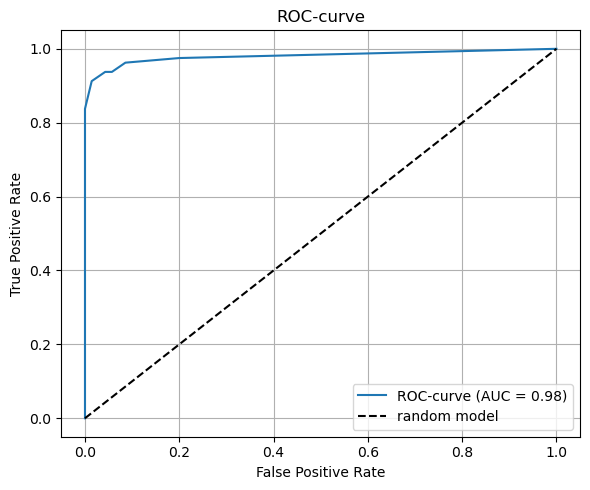

In [102]:
ROC_curve(y_test,X_test_proba[:, 1])

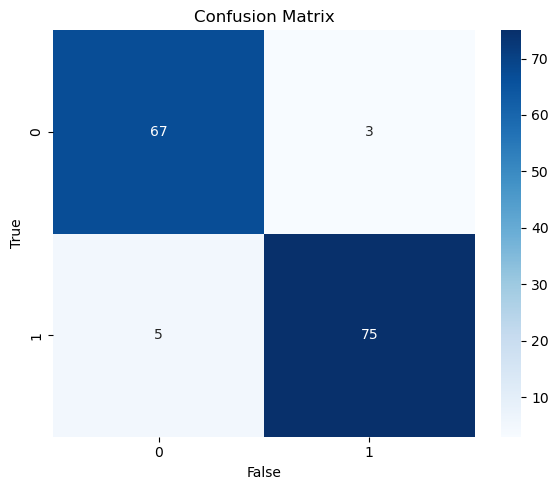

In [103]:
plot_custom_confusion_matrix(y_test, X_test_pred,labels=[0, 1], normalize=False)

In [104]:
results = metrics_gridsearch ("Knn_model", y_test, y_train, X_test_pred, X_test_proba[:, 1], X_train_pred, X_train_proba[:, 1],predict_time, results)

### SVM model

In [105]:
X_train,X_test, y_train, y_test  =train_test_split(
    data_for_engin.drop(['Retire'], axis=1),
    data_for_engin['Retire'], 
    random_state = 0,
    test_size=0.3
)
X_train.shape, X_test.shape

((350, 3), (150, 3))

In [106]:
SVC_pipeline = Pipeline(steps=[
    ('imputer', MeanMedianImputer(imputation_method='mean')),
    ('transformer', vt.YeoJohnsonTransformer()),
    ('scaler', StandardScaler()),
    ('model', SVC(C=0.3, kernel='linear', random_state=0,probability=True))
])

In [107]:
SVC_pipeline.fit(X_train,y_train)

Pipeline(steps=[('imputer', MeanMedianImputer(imputation_method='mean')),
                ('transformer', YeoJohnsonTransformer()),
                ('scaler', StandardScaler()),
                ('model',
                 SVC(C=0.3, kernel='linear', probability=True,
                     random_state=0))])

In [108]:
X_train_proba, X_test_proba,X_train_pred,X_test_pred, predict_time = Metrics_char(SVC_pipeline, X_train, X_test)

 Время предсказания: 0.003 секунд
Train Set
SVC accuracy: 0.9429
Test Set
SVC accuracy: 0.9400

Train Set
SVC ROC-AUC: 0.9873
Test Set
SVC ROC-AUC: 0.9898
Train Set
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       180
           1       0.94      0.95      0.94       170

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350

Test Set
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        70
           1       0.96      0.93      0.94        80

    accuracy                           0.94       150
   macro avg       0.94      0.94      0.94       150
weighted avg       0.94      0.94      0.94       150



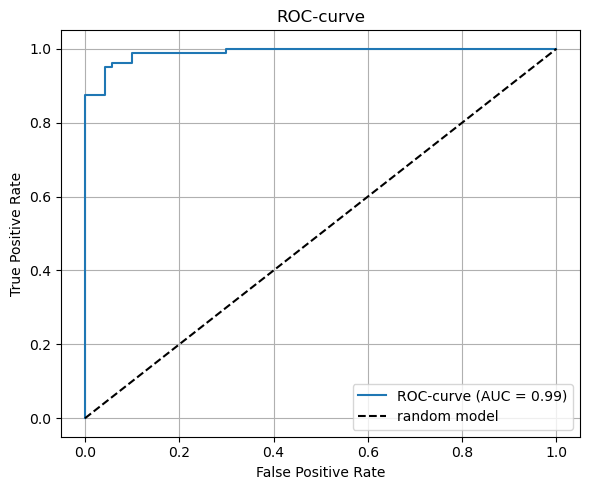

In [109]:
ROC_curve(y_test,X_test_proba[:, 1])

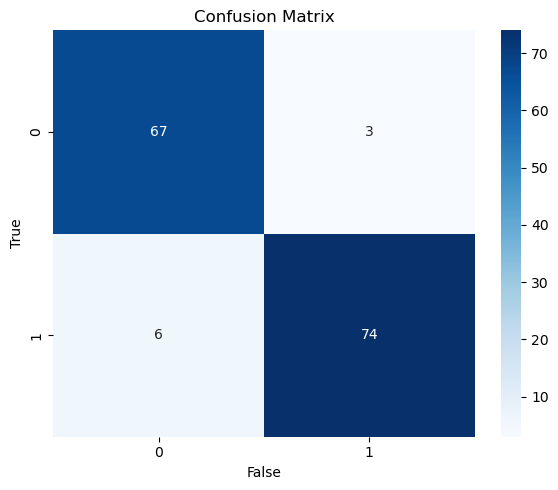

In [110]:
plot_custom_confusion_matrix(y_test, X_test_pred,labels=[0, 1], normalize=False)

In [111]:
results = metrics_gridsearch ("SVC_model", y_test, y_train, X_test_pred, X_test_proba[:, 1], X_train_pred, X_train_proba[:, 1],predict_time, results)

### Random Forest

In [112]:
X_train,X_test, y_train, y_test  =train_test_split(
    data_for_engin.drop(['Retire'], axis=1),
    data_for_engin['Retire'], 
    random_state = 0,
    test_size=0.3
)
X_train.shape, X_test.shape

((350, 3), (150, 3))

In [113]:
RF_pipeline = Pipeline(steps=[
    ('imputer', MeanMedianImputer(imputation_method='mean')),
    ('transformer', vt.YeoJohnsonTransformer()),
    #('scaler', StandardScaler()),
    ('model', RandomForestClassifier(max_depth=3,n_estimators=60, random_state=0))
])

In [114]:
RF_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', MeanMedianImputer(imputation_method='mean')),
                ('transformer', YeoJohnsonTransformer()),
                ('model',
                 RandomForestClassifier(max_depth=3, n_estimators=60,
                                        random_state=0))])

In [115]:
X_train_proba, X_test_proba,X_train_pred,X_test_pred,predict_time = Metrics_char(RF_pipeline, X_train, X_test)

 Время предсказания: 0.004 секунд
Train Set
RandomForestClassifier accuracy: 0.9543
Test Set
RandomForestClassifier accuracy: 0.9533

Train Set
RandomForestClassifier ROC-AUC: 0.9895
Test Set
RandomForestClassifier ROC-AUC: 0.9904
Train Set
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       180
           1       0.96      0.94      0.95       170

    accuracy                           0.95       350
   macro avg       0.95      0.95      0.95       350
weighted avg       0.95      0.95      0.95       350

Test Set
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        70
           1       0.97      0.94      0.96        80

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



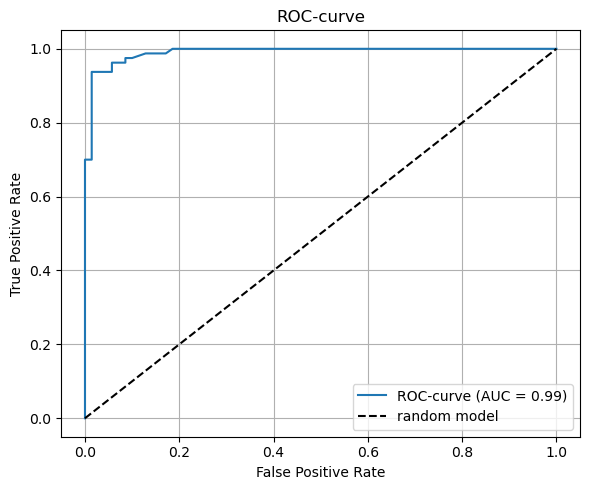

In [116]:
ROC_curve(y_test,X_test_proba[:, 1])

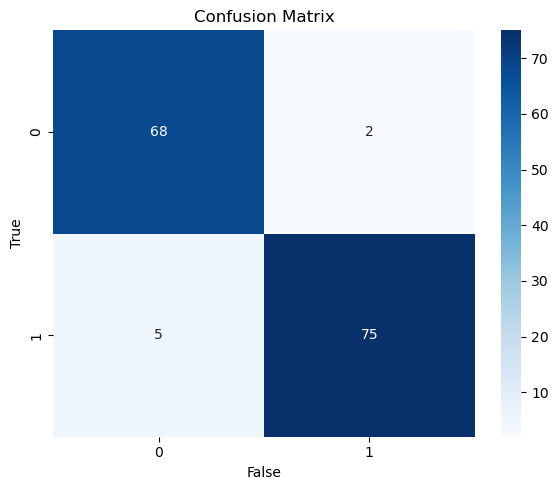

In [117]:
plot_custom_confusion_matrix(y_test, X_test_pred,labels=[0, 1], normalize=False)

In [118]:
results = metrics_gridsearch ("RandomForest_model", y_test, y_train, X_test_pred, X_test_proba[:, 1], X_train_pred, X_train_proba[:, 1],predict_time, results)

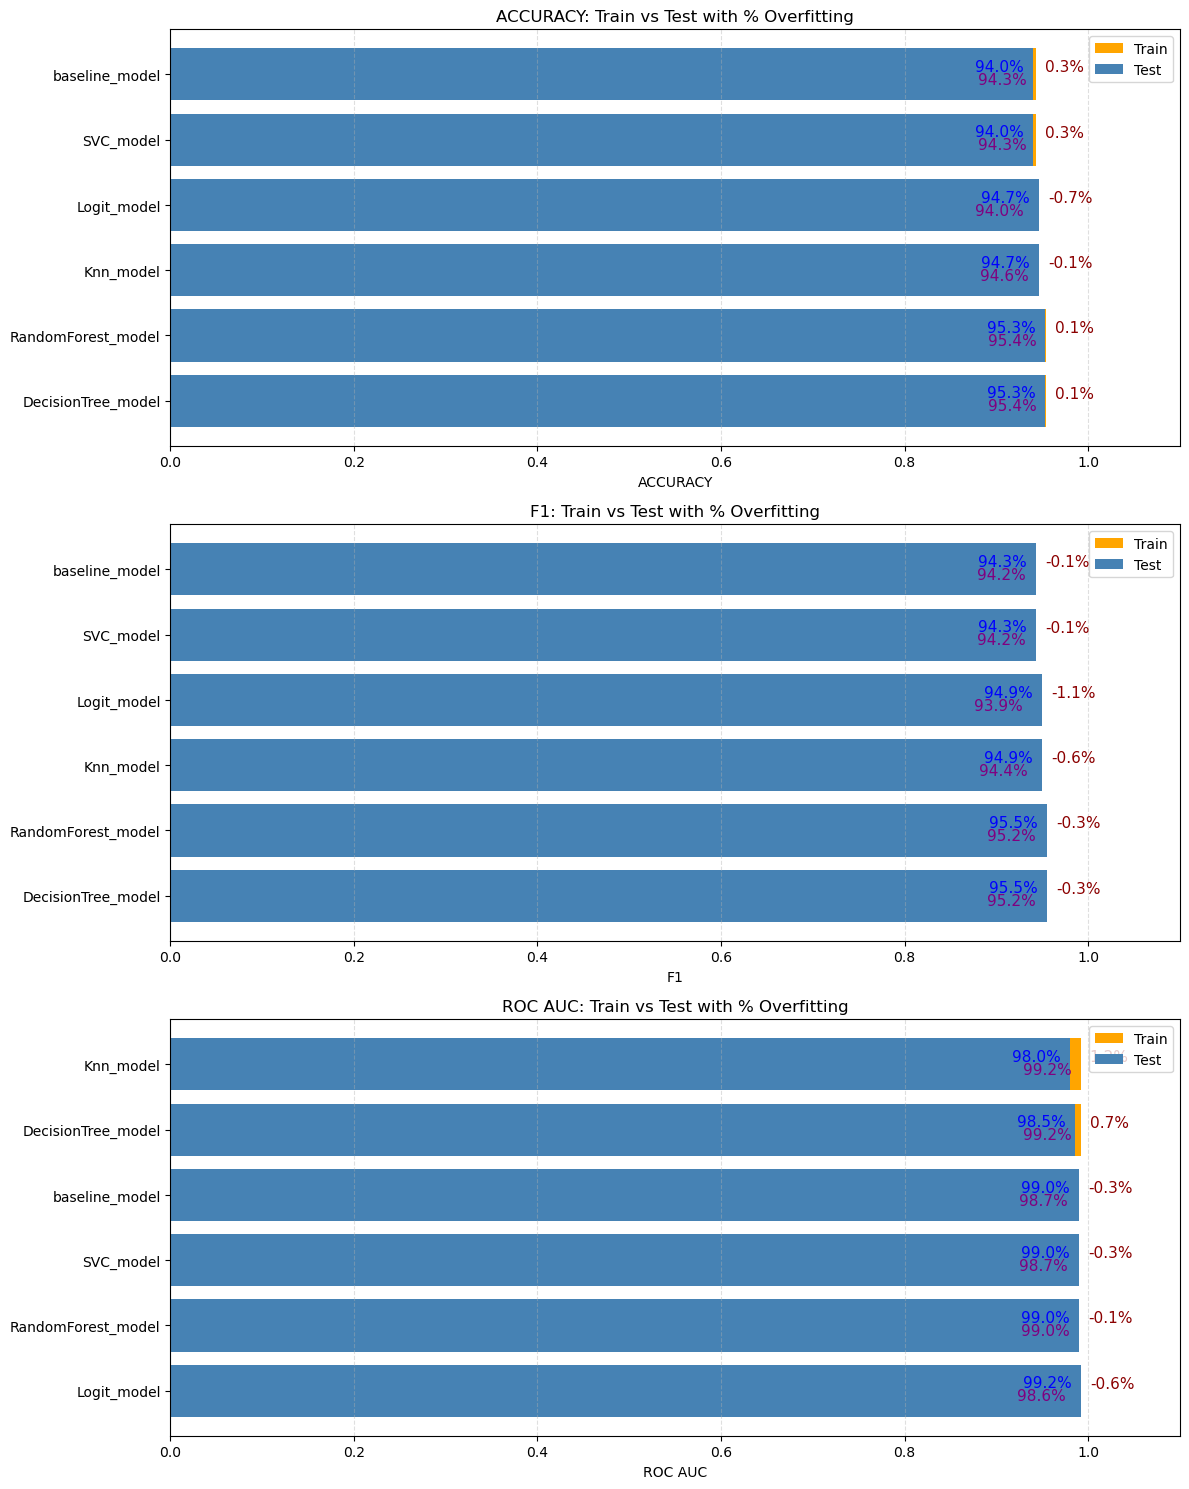

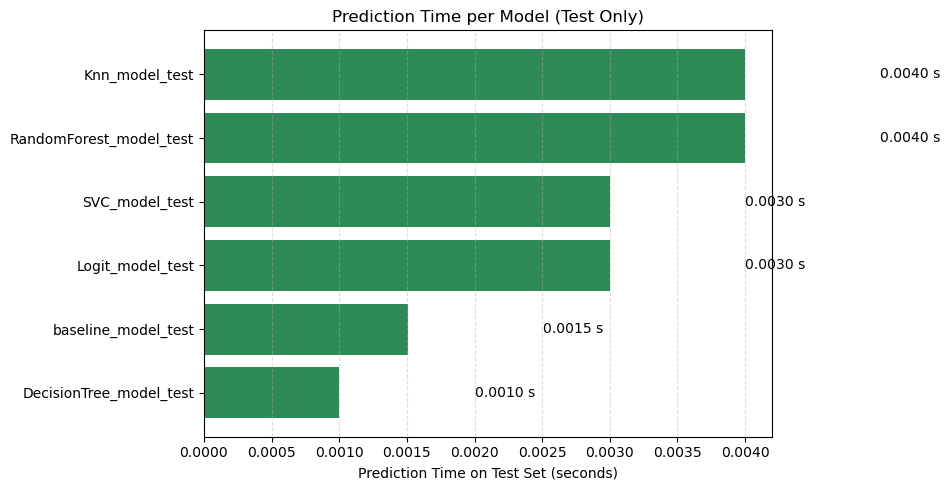

In [119]:
plot_metrics_overfit_summary(results, metrics_list=['Accuracy', 'F1', 'ROC AUC'])

## Conclusion 

Все модели отлично отрабатывают и имеют хорошие показатели , отсутствие переобучения и быструю предективную скорость.
Переменная "SavingsPerAge" имеет положительное влияние на некоторые модели , улучшая некоторые метрики. Из-за малого количества переменных и данных не удалось преодолеть accuracy выше 95%. Вероятно лучшей моделью и более сбалансированной является **RandomForest**
